# AyurAI — Malnutrition / Nutrition-Risk ML Pipeline (full notebook)
**AyurAI is a screening / risk-support system, NOT a diagnostic system.**
Run all cells top to bottom (Runtime → Run all). No tokens, no ngrok, no Google login needed.
Upload `malnutrition_data (1).csv`, `IND-Jaipur-2022.csv`, `IIH2007_Public_Use.csv` to /content first.
Outputs are saved to `/content/ayurai_outputs` (and zipped at the end).

In [2]:
# ============================================================
# CELL 0.1 — DATASET PATHS & FILE CHECK
# ============================================================

from pathlib import Path
import os

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------

MALNUTRITION_PATH = Path("/content/malnutrition_data (1).csv")
JAIPUR_PATH = Path("/content/IND-Jaipur-2022.csv")

# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

print("=" * 60)
print("DATASET FILE CHECK")
print("=" * 60)

for name, path in {
    "Primary Malnutrition Dataset": MALNUTRITION_PATH,
    "Jaipur GSHS 2022 Dataset": JAIPUR_PATH
}.items():

    print(f"\n{name}")
    print(f"Path: {path}")

    if path.exists():
        print(f"✅ FOUND")
        print(f"Size: {path.stat().st_size / (1024**2):.2f} MB")
    else:
        print("❌ NOT FOUND")

print("\n" + "=" * 60)

DATASET FILE CHECK

Primary Malnutrition Dataset
Path: /content/malnutrition_data (1).csv
✅ FOUND
Size: 0.39 MB

Jaipur GSHS 2022 Dataset
Path: /content/IND-Jaipur-2022.csv
✅ FOUND
Size: 1.69 MB



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# CELL 0.2 — Imports, config, helpers
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
OUT_DIR = "/content/ayurai_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 200)

# Optional manual overrides (leave None to auto-detect)
PATH_A = None; PATH_B = None; PATH_C = None
NORMAL_CLASS_OVERRIDE = None   # e.g. "normal" if auto-detection fails

def save_fig(name):
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{name}.png", dpi=130, bbox_inches="tight"); plt.show()

def read_csv_safe(path):
    last = None
    for enc in ["utf-8", "utf-8-sig", "latin-1"]:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False)
            if df.shape[1] == 1:
                for sep in [";", "\t", "|"]:
                    d2 = pd.read_csv(path, encoding=enc, sep=sep, low_memory=False)
                    if d2.shape[1] > 1: df = d2; break
            return df
        except Exception as e:
            last = e
    raise RuntimeError(f"Cannot read {path}: {last}")

def human_size(n):
    for u in ["B", "KB", "MB", "GB"]:
        if n < 1024: return f"{n:.1f} {u}"
        n /= 1024
    return f"{n:.1f} TB"

In [6]:
# CELL 1.1 — File discovery (read-only)

import os
import glob

roots = [r for r in ["/content", "/content/drive/MyDrive", os.getcwd()] if os.path.isdir(r)]

all_csvs = sorted({
    os.path.abspath(p)
    for r in roots
    for p in glob.glob(
        os.path.join(r, "**", "*.csv"),
        recursive=True
    )
    if "/sample_data/" not in p
    and "ayurai_outputs" not in p
})

print("CSV files found:")
for p in all_csvs:
    print("  -", p)

CSV files found:
  - /content/IND-Jaipur-2022.csv
  - /content/malnutrition_data (1).csv


In [8]:
# ============================================================
# CELL 1.2 — Load Dataset A
# ============================================================

import pandas as pd
import os

PATH_A = "/content/malnutrition_data (1).csv"

if not os.path.exists(PATH_A):
    raise FileNotFoundError(
        f"Dataset A not found: {PATH_A}\n"
        "Please upload malnutrition_data (1).csv to Colab first."
    )

dfA_raw = pd.read_csv(PATH_A)

print("✅ Dataset A loaded successfully")
print("Path:", PATH_A)
print("Shape:", dfA_raw.shape)
print("\nColumns:")
print(list(dfA_raw.columns))

✅ Dataset A loaded successfully
Path: /content/malnutrition_data (1).csv
Shape: (5000, 6)

Columns:
['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi', 'nutrition_status']


In [10]:
# CELL 0.1 — Environment and dependency initialization
# No datasets loaded. Nothing cleaned. Nothing trained. No token needed.

import sys, os, io, re, glob, json, math, platform, warnings, datetime, importlib, importlib.util, subprocess

# ---------- 1. Install ONLY packages that are missing (no token needed) ----------
_needed = {"xgboost": "xgboost", "shap": "shap", "imblearn": "imbalanced-learn"}
_missing = [pip_name for mod, pip_name in _needed.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Installing missing packages:", _missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])
else:
    print("All required packages already installed; nothing to install.")

# ---------- 2. Imports used across the whole notebook ----------
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import xgboost
import shap
import imblearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ---------- 3. Global constants ----------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PATH_A = "/content/malnutrition_data (1).csv"
PATH_B = "/content/IND-Jaipur-2022.csv"

OUTPUT_DIR = "/content/ayurai_malnutrition_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- 4. Display settings ----------
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
sns.set_style("whitegrid")

# ---------- 5. Reusable helpers (defined once, here) ----------
def human_size(n_bytes):
    """Convert a byte count to a readable string."""
    n = float(n_bytes)
    for unit in ["B", "KB", "MB", "GB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} TB"

def require(names, hint="Run the previous cells in order."):
    """Stop with a clear message if required objects are not defined yet."""
    missing = [x for x in names if x not in globals()]
    if missing:
        raise RuntimeError(f"Required objects are missing: {missing}. {hint}")

def save_fig(filename):
    """Save the current matplotlib figure into OUTPUT_DIR and show it."""
    path = os.path.join(OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved plot:", path)

# ---------- 6. Version report ----------
print("\n" + "=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print(f"Python       : {sys.version.split()[0]}")
print(f"Platform     : {platform.platform()}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgboost.__version__}")
print(f"shap         : {shap.__version__}")
print(f"imbalanced-learn : {imblearn.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"joblib       : {joblib.__version__}")
print("GPU          : not needed (tabular data, CPU only). TensorFlow not installed.")

print("\nRANDOM_STATE :", RANDOM_STATE)
print("PATH_A       :", PATH_A)
print("PATH_B       :", PATH_B)
print("OUTPUT_DIR   :", OUTPUT_DIR, "| exists:", os.path.isdir(OUTPUT_DIR))
print("Run date     :", datetime.datetime.now().isoformat(timespec="seconds"))

print("\nEnvironment ready.")
print("No dataset modified.")
print("No training performed.")

All required packages already installed; nothing to install.

ENVIRONMENT
Python       : 3.13.15
Platform     : Linux-6.6.122+-x86_64-with-glibc2.39
pandas       : 2.2.3
numpy        : 2.1.3
scikit-learn : 1.6.1
xgboost      : 3.4.1
shap         : 0.52.0
imbalanced-learn : 0.14.2
matplotlib   : 3.10.0
seaborn      : 0.13.2
joblib       : 1.6.0
GPU          : not needed (tabular data, CPU only). TensorFlow not installed.

RANDOM_STATE : 42
PATH_A       : /content/malnutrition_data (1).csv
PATH_B       : /content/IND-Jaipur-2022.csv
OUTPUT_DIR   : /content/ayurai_malnutrition_outputs | exists: True
Run date     : 2026-10-01T09:56:50

Environment ready.
No dataset modified.
No training performed.


In [12]:
# CELL 1.1 — File discovery
require(["PATH_A", "PATH_B", "human_size", "glob", "os", "pd"])

def read_csv_safe(path, nrows=None):
    """Read a CSV trying several encodings; never modifies the file."""
    last_err = None
    for enc in ["utf-8", "utf-8-sig", "latin-1"]:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False, nrows=nrows)
            if df.shape[1] == 1:                      # wrong delimiter?
                for sep in [";", "\t", "|"]:
                    d2 = pd.read_csv(path, encoding=enc, sep=sep, low_memory=False, nrows=nrows)
                    if d2.shape[1] > 1:
                        return d2
            return df
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Could not read {path}: {last_err}")

FILE_INFO = {}
for label, path in [("Dataset A (malnutrition)", PATH_A), ("Dataset B (Jaipur 2022)", PATH_B)]:
    print("=" * 70); print(label); print("Path  :", path)
    if not os.path.exists(path):
        print("NOT FOUND. CSV files currently in /content:")
        for p in sorted(glob.glob("/content/*.csv")): print("   ", p)
        raise FileNotFoundError(f"{path} does not exist. Upload it or fix PATH_A/PATH_B in Cell 0.1.")
    size = os.path.getsize(path)
    head = read_csv_safe(path, nrows=3)
    FILE_INFO[label] = {"path": path, "bytes": size}
    print("Size  :", human_size(size), f"({size:,} bytes)")
    print("Header columns:", head.shape[1])
    print("First 15 columns:", list(head.columns[:15]))

print("\nBoth files found and readable. Nothing modified.")

Dataset A (malnutrition)
Path  : /content/malnutrition_data (1).csv
Size  : 394.9 KB (404,360 bytes)
Header columns: 6
First 15 columns: ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi', 'nutrition_status']
Dataset B (Jaipur 2022)
Path  : /content/IND-Jaipur-2022.csv
Size  : 1.7 MB (1,775,249 bytes)
Header columns: 205
First 15 columns: ['record_id', 'stratum', 'psu', 'weight', 'de_age', 'de_sex', 'de_grade', 'db_height', 'db_weight', 'db_hungry', 'db_fruit', 'db_veg', 'db_soda', 'db_ssb', 'db_fat']

Both files found and readable. Nothing modified.


In [ ]:
# CELL 3.2 — Data dictionaries for Dataset B (Jaipur) and C (IIH2007)
meaning_B = {
    "de_age": "Student age (GSHS usually stores age as category codes — verify)", "de_sex": "Sex", "de_grade": "School grade",
    "db_height": "Height (check unit: metres vs cm)", "db_weight": "Weight (kg)", "db_hungry": "Frequency of going hungry",
    "db_fruit": "Fruit intake frequency", "db_veg": "Vegetable intake frequency", "db_soda": "Carbonated soft-drink frequency",
    "db_ssb": "Sugar-sweetened beverage frequency", "db_fat": "Fatty food frequency", "db_sugar": "Sugar-related behaviour",
    "db_underwt": "Underweight indicator (survey-derived; likely from BMI-for-age)", "db_overwt": "Overweight indicator (survey-derived)",
    "db_obese": "Obesity indicator (survey-derived)"}
HEALTH_KEYS = r"age|sex|grade|height|weight|bmi|hungry|food|fruit|veg|soda|ssb|fat|sugar|underwt|overwt|obese|nutri|muac|arm|meal|diet|anaem|anem|iron|health|illness|breakfast|water"
def build_dict(df, meanings=None):
    d = audit_table(df)
    d["meaning"] = d.column.map(lambda c: (meanings or {}).get(c, "not documented in prompt — review codebook"))
    d["health_related_guess"] = d.column.str.lower().str.contains(HEALTH_KEYS)
    d["decision"] = np.where(d.column.isin((meanings or {}).keys()), "REVIEW for compatibility; keep all", "KEEP in raw; do not drop")
    return d
dictB = build_dict(dfB_raw, meaning_B); dictC = build_dict(dfC_raw)
dictB.to_csv(f"{OUT_DIR}/data_dictionary_B_jaipur.csv", index=False); dictC.to_csv(f"{OUT_DIR}/data_dictionary_C_iih2007.csv", index=False)
print("B columns listed in your prompt but absent:", [c for c in meaning_B if c not in dfB_raw.columns])
display(dictB[dictB.column.isin(meaning_B.keys())])
print(f"\nB total columns {dfB_raw.shape[1]}; C total columns {dfC_raw.shape[1]} (full dictionaries saved to CSV, nothing dropped)")

In [13]:
# CELL 2.1 — Load raw data (these two dataframes are NEVER modified later)
require(["read_csv_safe", "PATH_A", "PATH_B"])

dfA_raw = read_csv_safe(PATH_A)
dfB_raw = read_csv_safe(PATH_B)

print("Dataset A raw shape :", dfA_raw.shape)
print("Dataset B raw shape :", dfB_raw.shape)
print("\nDataset A columns:", list(dfA_raw.columns))
print("\nDataset A head:"); display(dfA_raw.head())
hdr_ws_A = [c for c in dfA_raw.columns if str(c) != str(c).strip()]
print("Dataset A column names with leading/trailing whitespace:", hdr_ws_A)
print("\nDataset B: first 40 columns:", list(dfB_raw.columns[:40]))
print("\nRaw dataframes loaded. Nothing cleaned.")

Dataset A raw shape : (5000, 6)
Dataset B raw shape : (4299, 205)

Dataset A columns: ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi', 'nutrition_status']

Dataset A head:


,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal


Dataset A column names with leading/trailing whitespace: []

Dataset B: first 40 columns: ['record_id', 'stratum', 'psu', 'weight', 'de_age', 'de_sex', 'de_grade', 'db_height', 'db_weight', 'db_hungry', 'db_fruit', 'db_veg', 'db_soda', 'db_ssb', 'db_fat', 'db_sugar', 'hy_clteeth', 'hy_oralprob', 'hy_washeat', 'hy_washtoilet', 'hy_clwater', 'hy_septoilets', 'hy_teachwormtrt', 'in_timesinj', 'in_typeinj', 'in_causeinj', 'in_attack', 'in_bullsch', 'in_bullnosch', 'in_cyberbull', 'in_sbriding', 'in_helmetriding', 'in_teachavoidacc', 'mh_friends', 'mh_lonely', 'mh_worry', 'mh_depressed', 'mh_considersui', 'mh_plansui', 'mh_attemptsui']

Raw dataframes loaded. Nothing cleaned.


In [14]:
# CELL 3.1 — Deep audit: Dataset A
require(["dfA_raw", "np", "pd"])

def audit_table(df):
    """Per-column audit: dtype, missing, uniqueness, numeric range."""
    rows = []
    for c in df.columns:
        s = df[c]
        r = {"column": c, "dtype": str(s.dtype), "missing_count": int(s.isna().sum()),
             "missing_percentage": round(100 * s.isna().mean(), 2), "unique_values": int(s.nunique(dropna=True))}
        sn = pd.to_numeric(s, errors="coerce")
        if sn.notna().mean() > 0.9:
            r.update(min=sn.min(), median=sn.median(), max=sn.max())
        rows.append(r)
    return pd.DataFrame(rows)

EXPECTED_A = ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi", "nutrition_status"]
_lower = {str(c).strip().lower(): c for c in dfA_raw.columns}
COLS_A = {e: _lower.get(e) for e in EXPECTED_A}
_missing = [e for e, v in COLS_A.items() if v is None]
if _missing:
    print("Actual columns:", list(dfA_raw.columns))
    raise RuntimeError(f"Expected columns not found in Dataset A: {_missing}. Send me the column list.")
STD_FEATURES = ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi"]
TARGET_RAW = COLS_A["nutrition_status"]
print("Column mapping (standard -> actual):", COLS_A)

print("\nShape:", dfA_raw.shape)
print("Exact duplicate rows:", int(dfA_raw.duplicated().sum()))
print("\nPer-column audit:"); display(audit_table(dfA_raw))

print("\nRaw target values (repr exposes hidden whitespace/case variants):")
print(dfA_raw[TARGET_RAW].map(repr).value_counts(dropna=False).head(30))

print("\nNumeric sanity (reported only, nothing removed):")
for std in STD_FEATURES:
    s = pd.to_numeric(dfA_raw[COLS_A[std]], errors="coerce")
    print(f"{std:<11} negative={int((s<0).sum()):<4} zero={int((s==0).sum()):<4} missing/non-numeric={int(s.isna().sum()):<5} "
          f"min={s.min():.2f} p1={s.quantile(.01):.2f} median={s.median():.2f} p99={s.quantile(.99):.2f} max={s.max():.2f}")

CODED = {"", "na", "n/a", "nan", "null", "none", "?", "-", "--", "unknown"}
print("\nPossible coded-missing strings in text columns:")
for c in dfA_raw.select_dtypes(include="object").columns:
    n = int(dfA_raw[c].astype(str).str.strip().str.lower().isin(CODED).sum() - dfA_raw[c].isna().sum())
    print(f"  {c}: {max(n,0)}")
print("\nAudit A complete. Nothing modified.")

Column mapping (standard -> actual): {'age_months': 'age_months', 'weight_kg': 'weight_kg', 'height_cm': 'height_cm', 'muac_cm': 'muac_cm', 'bmi': 'bmi', 'nutrition_status': 'nutrition_status'}

Shape: (5000, 6)
Exact duplicate rows: 0

Per-column audit:


,column,dtype,missing_count,missing_percentage,unique_values,min,median,max
0,age_months,float64,0,0.0,5000,1.000686,30.607902,59.989601
1,weight_kg,float64,0,0.0,3383,3.000000,4.648996,10.726919
2,height_cm,float64,0,0.0,4791,45.000000,75.010021,105.000000
3,muac_cm,float64,0,0.0,5000,10.261992,13.635633,15.715103
4,bmi,float64,0,0.0,83,10.000000,10.000000,11.285436
5,nutrition_status,object,0,0.0,3,NaN,NaN,NaN



Raw target values (repr exposes hidden whitespace/case variants):
nutrition_status
'normal'      3550
'moderate'    1100
'severe'       350
Name: count, dtype: int64

Numeric sanity (reported only, nothing removed):
age_months  negative=0    zero=0    missing/non-numeric=0     min=1.00 p1=1.59 median=30.61 p99=59.41 max=59.99
weight_kg   negative=0    zero=0    missing/non-numeric=0     min=3.00 p1=3.00 median=4.65 p99=10.38 max=10.73
height_cm   negative=0    zero=0    missing/non-numeric=0     min=45.00 p1=45.27 median=75.01 p99=105.00 max=105.00
muac_cm     negative=0    zero=0    missing/non-numeric=0     min=10.26 p1=11.22 median=13.64 p99=15.02 max=15.72
bmi         negative=0    zero=0    missing/non-numeric=0     min=10.00 p1=10.00 median=10.00 p99=10.13 max=11.29

Possible coded-missing strings in text columns:
  nutrition_status: 0

Audit A complete. Nothing modified.


In [15]:
# CELL 3.2 — Deep audit: Dataset B (Jaipur)
require(["dfB_raw", "audit_table", "np", "pd", "re"])

B_EXPECTED = ["de_age", "de_sex", "de_grade", "db_height", "db_weight", "db_hungry", "db_fruit", "db_veg",
              "db_soda", "db_ssb", "db_fat", "db_sugar", "db_underwt", "db_overwt", "db_obese"]
HEALTH_REGEX = r"age|sex|grade|height|weight|bmi|hungry|food|fruit|veg|soda|ssb|fat|sugar|underwt|overwt|obese|nutri|muac|arm|meal|diet|breakfast|water"
_lowerB = {str(c).strip().lower(): c for c in dfB_raw.columns}
B_PRESENT = {c: _lowerB[c] for c in B_EXPECTED if c in _lowerB}
print("Shape:", dfB_raw.shape)
print("Expected columns present:", list(B_PRESENT))
print("Expected columns ABSENT :", [c for c in B_EXPECTED if c not in B_PRESENT])
print("Exact duplicate rows    :", int(dfB_raw.duplicated().sum()))

display(audit_table(dfB_raw[list(B_PRESENT.values())]))
print("\nValue distributions for low-cardinality columns (NaN included):")
for std, actual in B_PRESENT.items():
    if dfB_raw[actual].nunique() <= 12:
        print(f"\n{std}:", dfB_raw[actual].value_counts(dropna=False).sort_index().to_dict())

muac_like = [c for c in dfB_raw.columns if re.search(r"muac|arm.?circ|midupper", str(c).lower())]
print("\nMUAC-like columns in Jaipur:", muac_like)
hits = [c for c in dfB_raw.columns if re.search(HEALTH_REGEX, str(c).lower())]
print(f"\nHealth/nutrition-like columns by name ({len(hits)}):", hits[:80])
print("\nAudit B complete. Nothing modified.")

Shape: (4299, 205)
Expected columns present: ['de_age', 'de_sex', 'de_grade', 'db_height', 'db_weight', 'db_hungry', 'db_fruit', 'db_veg', 'db_soda', 'db_ssb', 'db_fat', 'db_sugar', 'db_underwt', 'db_overwt', 'db_obese']
Expected columns ABSENT : []
Exact duplicate rows    : 0


,column,dtype,missing_count,missing_percentage,unique_values,min,median,max
0,de_age,float64,26,0.60,8,1.0,4.0,8.0
1,de_sex,float64,50,1.16,2,1.0,1.0,2.0
2,de_grade,float64,27,0.63,6,1.0,3.0,6.0
3,db_height,float64,4,0.09,68,115.0,157.0,199.0
4,db_weight,float64,5,0.12,84,13.0,46.0,116.0
5,db_hungry,float64,62,1.44,5,1.0,1.0,5.0
6,db_fruit,float64,35,0.81,7,1.0,3.0,7.0
7,db_veg,float64,79,1.84,7,1.0,4.0,7.0
8,db_soda,float64,56,1.30,7,1.0,1.0,7.0
9,db_ssb,float64,70,1.63,7,1.0,2.0,7.0



Value distributions for low-cardinality columns (NaN included):

de_age: {1.0: 128, 2.0: 497, 3.0: 692, 4.0: 889, 5.0: 829, 6.0: 617, 7.0: 461, 8.0: 160, nan: 26}

de_sex: {1.0: 2276, 2.0: 1973, nan: 50}

de_grade: {1.0: 808, 2.0: 746, 3.0: 818, 4.0: 820, 5.0: 531, 6.0: 549, nan: 27}

db_hungry: {1.0: 2806, 2.0: 705, 3.0: 511, 4.0: 121, 5.0: 94, nan: 62}

db_fruit: {1.0: 601, 2.0: 1383, 3.0: 694, 4.0: 959, 5.0: 412, 6.0: 115, 7.0: 100, nan: 35}

db_veg: {1.0: 148, 2.0: 882, 3.0: 848, 4.0: 585, 5.0: 1073, 6.0: 505, 7.0: 179, nan: 79}

db_soda: {1.0: 2326, 2.0: 991, 3.0: 230, 4.0: 471, 5.0: 92, 6.0: 54, 7.0: 79, nan: 56}

db_ssb: {1.0: 1598, 2.0: 1126, 3.0: 325, 4.0: 752, 5.0: 294, 6.0: 73, 7.0: 61, nan: 70}

db_fat: {1.0: 1030, 2.0: 1910, 3.0: 499, 4.0: 509, 5.0: 164, 6.0: 82, 7.0: 48, nan: 57}

db_sugar: {1.0: 853, 2.0: 1685, 3.0: 627, 4.0: 649, 5.0: 231, 6.0: 109, 7.0: 88, nan: 57}

db_underwt: {1.0: 881, 2.0: 3335, nan: 83}

db_overwt: {1.0: 579, 2.0: 3637, nan: 83}

db_obese: {1.0:

In [17]:
# CELL 4.1 — Data dictionary: Dataset A
require(["dfA_raw", "audit_table", "COLS_A", "OUTPUT_DIR", "pd", "os"])

meta_A = {  # standard name: (meaning, potential_importance, leakage_risk, decision)
    "age_months": ("Child age in months (units verified in Cell 5.2)", "Defines population; modifies interpretation of other measures", "Low", "KEEP as feature"),
    "weight_kg": ("Body weight in kg", "Core anthropometric", "Medium-High if label derived from weight-based indices", "KEEP as feature"),
    "height_cm": ("Height/length in cm", "Core anthropometric", "Medium-High if label derived from height-based indices", "KEEP as feature"),
    "muac_cm": ("Mid-upper-arm circumference in cm", "Established nutrition-screening measure", "Medium-High if label derived from MUAC cut-offs", "KEEP as feature"),
    "bmi": ("Body-mass index (derived from weight and height?)", "Summary of weight-for-height", "HIGH: derived/redundant; tested in Cells 5.2 and 9.2", "KEEP, report dependency"),
    "nutrition_status": ("Nutrition status class — TARGET", "Outcome label", "TARGET", "KEEP original; create *_clean copy"),
}
_rev = {v: k for k, v in COLS_A.items()}
dictA = audit_table(dfA_raw)[["column", "dtype", "missing_count", "missing_percentage", "unique_values"]].copy()
dictA["meaning"] = dictA.column.map(lambda c: meta_A.get(_rev.get(c), ("NOT DOCUMENTED — review manually",))[0])
dictA["potential_importance"] = dictA.column.map(lambda c: meta_A.get(_rev.get(c), ("", "Unknown"))[1])
dictA["leakage_risk"] = dictA.column.map(lambda c: meta_A.get(_rev.get(c), ("", "", "Unknown"))[2])
dictA["decision"] = dictA.column.map(lambda c: meta_A.get(_rev.get(c), ("", "", "", "QUARANTINE: keep in file, not used for training until reviewed"))[3])
dictA = dictA[["column", "meaning", "dtype", "missing_count", "missing_percentage", "unique_values",
               "potential_importance", "leakage_risk", "decision"]]
display(dictA)
dictA.to_csv(os.path.join(OUTPUT_DIR, "data_dictionary_A.csv"), index=False)
print("Saved data_dictionary_A.csv")

,column,meaning,dtype,missing_count,missing_percentage,unique_values,potential_importance,leakage_risk,decision
0,age_months,Child age in months (units verified in Cell 5.2),float64,0,0.0,5000,Defines population; modifies interpretation of...,Low,KEEP as feature
1,weight_kg,Body weight in kg,float64,0,0.0,3383,Core anthropometric,Medium-High if label derived from weight-based...,KEEP as feature
2,height_cm,Height/length in cm,float64,0,0.0,4791,Core anthropometric,Medium-High if label derived from height-based...,KEEP as feature
3,muac_cm,Mid-upper-arm circumference in cm,float64,0,0.0,5000,Established nutrition-screening measure,Medium-High if label derived from MUAC cut-offs,KEEP as feature
4,bmi,Body-mass index (derived from weight and height?),float64,0,0.0,83,Summary of weight-for-height,HIGH: derived/redundant; tested in Cells 5.2 a...,"KEEP, report dependency"
5,nutrition_status,Nutrition status class — TARGET,object,0,0.0,3,Outcome label,TARGET,KEEP original; create *_clean copy


Saved data_dictionary_A.csv


In [18]:
# CELL 4.2 — Data dictionary: Dataset B (Jaipur)
require(["dfB_raw", "audit_table", "B_PRESENT", "HEALTH_REGEX", "OUTPUT_DIR", "pd", "os", "re"])

meaning_B = {
    "de_age": "Student age (may be category codes, not years — verify)", "de_sex": "Sex", "de_grade": "School grade",
    "db_height": "Height (unit to be verified)", "db_weight": "Weight (kg?)", "db_hungry": "Frequency of going hungry",
    "db_fruit": "Fruit intake frequency", "db_veg": "Vegetable intake frequency", "db_soda": "Carbonated soft drink frequency",
    "db_ssb": "Sugar-sweetened beverage frequency", "db_fat": "Fatty-food frequency", "db_sugar": "Sugar-related behaviour",
    "db_underwt": "Underweight indicator (survey-derived)", "db_overwt": "Overweight indicator (survey-derived)",
    "db_obese": "Obesity indicator (survey-derived)"}
_revB = {v: k for k, v in B_PRESENT.items()}
dictB = audit_table(dfB_raw)[["column", "dtype", "missing_count", "missing_percentage", "unique_values"]].copy()
dictB["meaning"] = dictB.column.map(lambda c: meaning_B.get(_revB.get(c), "not documented here — check GSHS codebook"))
dictB["potential_importance"] = dictB.column.map(lambda c: "Possible nutrition/anthropometric relevance" if re.search(HEALTH_REGEX, str(c).lower()) else "Unknown")
dictB["leakage_risk"] = dictB.column.map(lambda c: "Possible outcome label (not used for training)" if _revB.get(c) in ("db_underwt", "db_overwt", "db_obese") else "n/a (Jaipur is not a training set)")
dictB["decision"] = "KEEP in raw; review before any use"
dictB = dictB[["column", "meaning", "dtype", "missing_count", "missing_percentage", "unique_values",
               "potential_importance", "leakage_risk", "decision"]]
dictB.to_csv(os.path.join(OUTPUT_DIR, "data_dictionary_B_jaipur.csv"), index=False)
display(dictB[dictB.column.isin(B_PRESENT.values())])
print(f"Full Jaipur dictionary ({len(dictB)} columns) saved. No column removed.")

,column,meaning,dtype,missing_count,missing_percentage,unique_values,potential_importance,leakage_risk,decision
4,de_age,"Student age (may be category codes, not years ...",float64,26,0.60,8,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
5,de_sex,Sex,float64,50,1.16,2,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
6,de_grade,School grade,float64,27,0.63,6,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
7,db_height,Height (unit to be verified),float64,4,0.09,68,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
8,db_weight,Weight (kg?),float64,5,0.12,84,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
9,db_hungry,Frequency of going hungry,float64,62,1.44,5,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
10,db_fruit,Fruit intake frequency,float64,35,0.81,7,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
11,db_veg,Vegetable intake frequency,float64,79,1.84,7,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
12,db_soda,Carbonated soft drink frequency,float64,56,1.30,7,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use
13,db_ssb,Sugar-sweetened beverage frequency,float64,70,1.63,7,Possible nutrition/anthropometric relevance,n/a (Jaipur is not a training set),KEEP in raw; review before any use


Full Jaipur dictionary (205 columns) saved. No column removed.


In [19]:
# CELL 5.1 — Safe cleaning (features). Raw dataframe is untouched.
require(["dfA_raw", "COLS_A", "STD_FEATURES", "TARGET_RAW", "np", "pd"])

dfA_clean = dfA_raw.copy()
dfA_clean = dfA_clean.rename(columns={v: k for k, v in COLS_A.items()})   # standard names

# 1) whitespace + empty strings + known coded-missing text (reported)
CODED = {"", "na", "n/a", "nan", "null", "none", "?", "--", "-"}
for c in dfA_clean.select_dtypes(include="object").columns:
    s = dfA_clean[c].apply(lambda v: v.strip() if isinstance(v, str) else v)
    n_conv = int(s.apply(lambda v: isinstance(v, str) and v.lower() in CODED).sum())
    dfA_clean[c] = s.apply(lambda v: np.nan if isinstance(v, str) and v.lower() in CODED else v)
    if n_conv: print(f"{c}: converted {n_conv} coded-missing strings to NaN")

# 2) numeric conversion (reports what became NaN)
for c in STD_FEATURES:
    before = int(dfA_clean[c].isna().sum())
    dfA_clean[c] = pd.to_numeric(dfA_clean[c], errors="coerce")
    print(f"{c:<11} dtype={dfA_clean[c].dtype}  new NaN from coercion={int(dfA_clean[c].isna().sum()) - before}")

# 3) flag (NOT remove) impossible values and suspicious sentinels
flags = pd.DataFrame({f"{c}<=0": dfA_clean[c] <= 0 for c in STD_FEATURES})
print("\nNon-positive values per feature (flagged, not changed here):"); print(flags.sum())
for c in STD_FEATURES:
    sent = int(dfA_clean[c].isin([999, -999, 9999, -1, 99, 88]).sum())
    if sent: print(f"⚠ {c}: {sent} values equal a common sentinel code (99/88/999/9999/-1). Inspect manually.")

print("\nraw shape:", dfA_raw.shape, "| clean shape:", dfA_clean.shape, "(no rows or columns removed)")
print("dfA_raw unchanged:", list(dfA_raw.columns) == list(pd.read_csv(PATH_A, nrows=0, encoding='utf-8', low_memory=False).columns) if os.path.exists(PATH_A) else "n/a")

age_months  dtype=float64  new NaN from coercion=0
weight_kg   dtype=float64  new NaN from coercion=0
height_cm   dtype=float64  new NaN from coercion=0
muac_cm     dtype=float64  new NaN from coercion=0
bmi         dtype=float64  new NaN from coercion=0

Non-positive values per feature (flagged, not changed here):
age_months<=0    0
weight_kg<=0     0
height_cm<=0     0
muac_cm<=0       0
bmi<=0           0
dtype: int64

raw shape: (5000, 6) | clean shape: (5000, 6) (no rows or columns removed)
dfA_raw unchanged: True


count    5000.00
mean       30.33
std        17.15
min         1.00
25%        15.30
50%        30.61
75%        45.14
max        59.99
Name: age_months, dtype: float64

Age range: 1–60 months  =  0.1–5.0 years

Age-band distribution:
age_months
<=0                       0
0–24 mo                1975
24–60 mo (to 5y)       3025
5–10y                     0
10–18y (school-age)       0
>18y                      0
Name: count, dtype: int64

Under 60 months: 100.0% | 60–215 months (5–<18y): 0.0%
⚠ POPULATION MISMATCH: Dataset A is MAINLY under-5 children. AyurAI targets school-age students, so the model must NOT be described as trained on Indian school students.


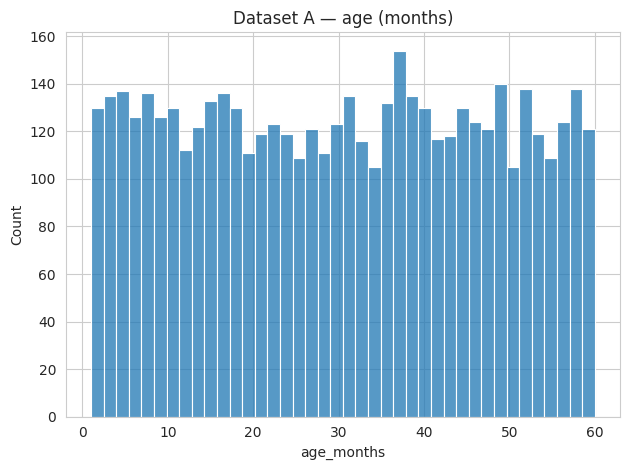

Saved plot: /content/ayurai_malnutrition_outputs/A_age_distribution.png

BMI vs weight/height²: corr=0.0763 | median|diff|=1.278 | within 0.1: 2.9% | within 0.5: 14.9%
BMI is (approximately) derived from weight and height: False


In [20]:
# CELL 5.2 — Age distribution, units, BMI derivation
require(["dfA_clean", "np", "pd", "plt", "sns", "save_fig"])

age = dfA_clean["age_months"].dropna()
print(age.describe().round(2))
print(f"\nAge range: {age.min():.0f}–{age.max():.0f} months  =  {age.min()/12:.1f}–{age.max()/12:.1f} years")
if age.max() <= 25:
    print("⚠ Max age ≤ 25: values may be YEARS, not months. Verify before trusting the column name.")
bins = [-np.inf, 0, 24, 60, 120, 216, np.inf]
labels = ["<=0", "0–24 mo", "24–60 mo (to 5y)", "5–10y", "10–18y (school-age)", ">18y"]
print("\nAge-band distribution:"); print(pd.cut(dfA_clean["age_months"], bins=bins, labels=labels).value_counts(dropna=False).sort_index())
share_u5 = 100 * (age < 60).mean(); share_school = 100 * ((age >= 60) & (age < 216)).mean()
print(f"\nUnder 60 months: {share_u5:.1f}% | 60–215 months (5–<18y): {share_school:.1f}%")
if share_u5 > 50:
    print("⚠ POPULATION MISMATCH: Dataset A is MAINLY under-5 children. AyurAI targets school-age students, "
          "so the model must NOT be described as trained on Indian school students.")
elif share_school > 50:
    print("Dataset A mainly covers school-age children.")
else:
    print("Dataset A is a mixed-age sample; see bands above.")

sns.histplot(age, bins=40); plt.title("Dataset A — age (months)"); plt.xlabel("age_months"); save_fig("A_age_distribution.png")

d = dfA_clean.dropna(subset=["weight_kg", "height_cm", "bmi"])
d = d[(d.height_cm > 0) & (d.weight_kg > 0)]
bmi_re = d.weight_kg / (d.height_cm / 100) ** 2
diff = (bmi_re - d.bmi).abs()
print(f"\nBMI vs weight/height²: corr={np.corrcoef(bmi_re, d.bmi)[0,1]:.4f} | median|diff|={diff.median():.3f} | within 0.1: {100*(diff<=0.1).mean():.1f}% | within 0.5: {100*(diff<=0.5).mean():.1f}%")
BMI_DERIVED = bool((diff <= 0.5).mean() > 0.9)
print("BMI is (approximately) derived from weight and height:", BMI_DERIVED)
if BMI_DERIVED:
    print("→ BMI adds no independent information; it is a redundant derived feature. Kept, but reported.")

In [21]:
# CELL 6.1 — Target preparation (original kept, clean copy created) + modelling frame
require(["dfA_raw", "dfA_clean", "TARGET_RAW", "STD_FEATURES", "OUTPUT_DIR", "np", "pd", "re", "os"])

dfA_clean["nutrition_status_original"] = dfA_raw[TARGET_RAW]          # untouched copy
print("Target dtype:", dfA_raw[TARGET_RAW].dtype)
if pd.api.types.is_numeric_dtype(dfA_raw[TARGET_RAW]):
    print("⚠ Target is numeric: class meanings are NOT documented in the file. Do not assume which number means what.")

def norm_key(x):
    return np.nan if pd.isna(x) else re.sub(r"[\s_\-]+", " ", str(x).strip().lower())
_keys = dfA_clean["nutrition_status_original"].map(norm_key)
CANON = {}
for k in _keys.dropna().unique():
    CANON[k] = dfA_clean.loc[_keys == k, "nutrition_status_original"].astype(str).str.strip().value_counts().index[0]
dfA_clean["nutrition_status_clean"] = _keys.map(CANON)       # only case/space/underscore normalisation; no new labels

print("\nNormalisation map (variants → clean label):")
for k, v in CANON.items():
    print(f"  {sorted(set(dfA_raw.loc[_keys == k, TARGET_RAW].astype(str)))}  →  '{v}'")
vc = dfA_clean["nutrition_status_clean"].value_counts(dropna=False)
print("\nClass distribution:"); display(pd.DataFrame({"count": vc, "percent": (100 * vc / len(dfA_clean)).round(2)}))
print("Missing labels:", int(dfA_clean["nutrition_status_clean"].isna().sum()))
print("Is the label observed or derived? NOT documented in the file — tested in Cell 6.2.")

# Modelling frame (dfA_clean itself is not changed)
dfA_model = dfA_clean.copy()
for c in STD_FEATURES:
    bad = dfA_model[c] <= 0
    if bad.any():
        print(f"{c}: setting {int(bad.sum())} non-positive values to NaN in the modelling frame (imputed later on TRAIN only)")
        dfA_model.loc[bad, c] = np.nan
n0 = len(dfA_model)
dfA_model = dfA_model.dropna(subset=["nutrition_status_clean"])
print(f"Dropped {n0 - len(dfA_model)} rows with missing target (cannot train without a label).")
n1 = len(dfA_model)
dfA_model = dfA_model.drop_duplicates(subset=STD_FEATURES + ["nutrition_status_clean"]).reset_index(drop=True)
print(f"Dropped {n1 - len(dfA_model)} exact duplicate (features + label) rows. Modelling rows: {len(dfA_model)}")
print("No child-ID column is used; repeat measurements of the same child cannot be verified.")
dfA_clean.to_csv(os.path.join(OUTPUT_DIR, "A_clean_full.csv"), index=False)
dfA_model.to_csv(os.path.join(OUTPUT_DIR, "A_modelling_frame.csv"), index=False)

Target dtype: object

Normalisation map (variants → clean label):
  ['normal']  →  'normal'
  ['moderate']  →  'moderate'
  ['severe']  →  'severe'

Class distribution:


,count,percent
nutrition_status_clean,,
normal,3550,71.0
moderate,1100,22.0
severe,350,7.0


Missing labels: 0
Is the label observed or derived? NOT documented in the file — tested in Cell 6.2.
Dropped 0 rows with missing target (cannot train without a label).
Dropped 0 exact duplicate (features + label) rows. Modelling rows: 5000
No child-ID column is used; repeat measurements of the same child cannot be verified.


In [22]:
# CELL 6.2 — Label/feature dependency diagnostics (reporting only)
require(["dfA_model", "STD_FEATURES", "RANDOM_STATE", "np", "pd", "StratifiedKFold", "cross_val_score", "DecisionTreeClassifier"])

yd = dfA_model["nutrition_status_clean"]
Xd = dfA_model[STD_FEATURES].fillna(dfA_model[STD_FEATURES].median())
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE) if yd.value_counts().min() >= 5 else 3

print("Per-class min–max of each feature (clean threshold-like separation suggests a rule-derived label):")
rng_tbl = dfA_model.groupby("nutrition_status_clean")[STD_FEATURES].agg(["min", "max"]).round(2)
display(rng_tbl)

LEAK_SCORES = {}
print("\nShallow decision tree (depth 4) 5-fold CV accuracy:")
for feats in [["bmi"], ["muac_cm"], ["weight_kg"], ["height_cm"], ["weight_kg", "height_cm"], ["age_months", "weight_kg", "height_cm"], ["bmi", "muac_cm"], STD_FEATURES]:
    sc = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE), Xd[feats], yd, cv=cv, scoring="accuracy").mean()
    LEAK_SCORES[", ".join(feats)] = float(sc); print(f"  {', '.join(feats):<36} {sc:.3f}")
MAJORITY = float(yd.value_counts(normalize=True).max())
print(f"  majority-class baseline: {MAJORITY:.3f}")
RULE_DERIVED_SUSPECTED = max(LEAK_SCORES.values()) >= 0.95
print("\nVERDICT:")
if RULE_DERIVED_SUSPECTED:
    print("⚠ The label is very likely RULE-DERIVED from these measurements (a shallow tree reproduces it almost perfectly).")
    print("  High accuracy then means 'reproduces the labelling rule', NOT independent prediction of nutritional status.")
else:
    print("A shallow tree does not reproduce the label almost perfectly. Dependence on the measurements is still likely, "
          "because status is usually defined from anthropometry, but the rule is not trivially recoverable.")

Per-class min–max of each feature (clean threshold-like separation suggests a rule-derived label):


age_months        weight_kg        height_cm         muac_cm          bmi       
                              min    max       min    max       min     max     min    max   min    max
nutrition_status_clean                                                                                 
moderate                     1.01  59.89       3.0   7.70      45.0  103.59   10.56  13.91  10.0  10.00
normal                       1.00  59.98       3.0  10.73      45.0  105.00   12.22  15.72  10.0  11.29
severe                       1.14  59.99       3.0   6.20      45.0   93.04   10.26  13.03  10.0  10.00


Shallow decision tree (depth 4) 5-fold CV accuracy:
  bmi                                  0.710
  muac_cm                              0.884
  weight_kg                            0.708
  height_cm                            0.709
  weight_kg, height_cm                 0.755
  age_months, weight_kg, height_cm     0.821
  bmi, muac_cm                         0.884
  age_months, weight_kg, height_cm, muac_cm, bmi 0.892
  majority-class baseline: 0.710

VERDICT:
A shallow tree does not reproduce the label almost perfectly. Dependence on the measurements is still likely, because status is usually defined from anthropometry, but the rule is not trivially recoverable.


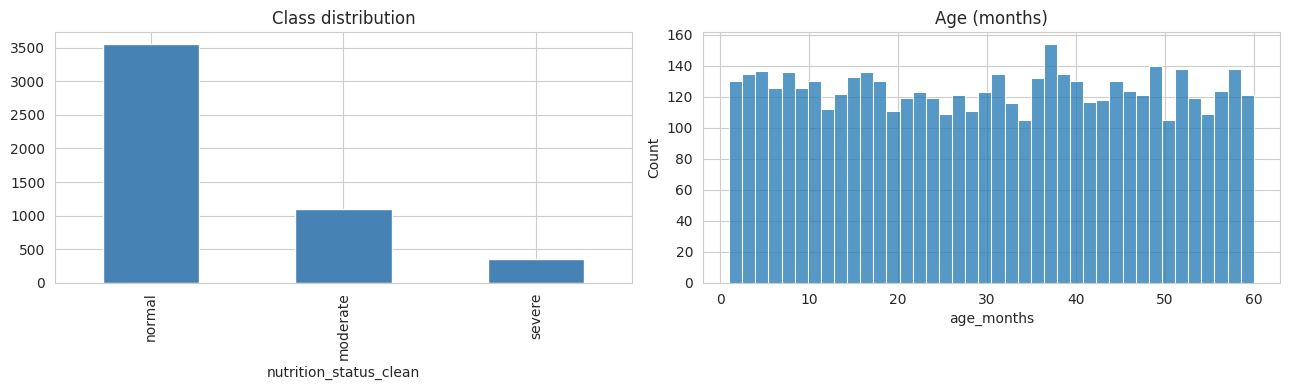

Saved plot: /content/ayurai_malnutrition_outputs/eda_class_age.png


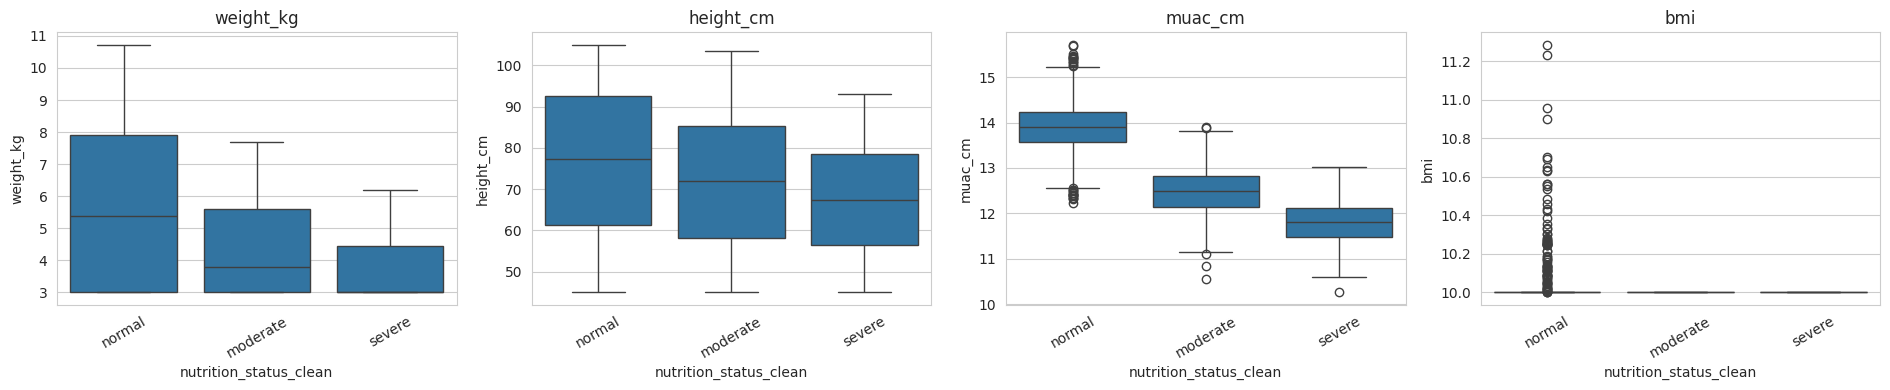

Saved plot: /content/ayurai_malnutrition_outputs/eda_boxplots.png


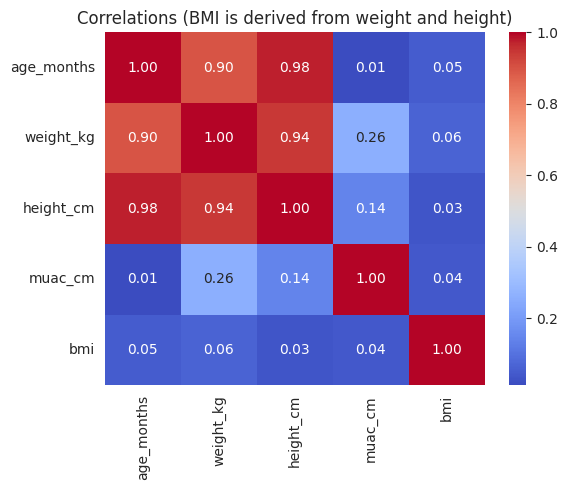

Saved plot: /content/ayurai_malnutrition_outputs/eda_correlation.png


,age_months,weight_kg,height_cm,muac_cm,bmi
nutrition_status_clean,,,,,
moderate,30.33,3.79,72.07,12.48,10.0
normal,30.82,5.38,77.26,13.89,10.0
severe,29.74,3.00,67.31,11.80,10.0


In [23]:
# CELL 7.1 — EDA (a few useful plots)
require(["dfA_model", "STD_FEATURES", "plt", "sns", "save_fig"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dfA_model["nutrition_status_clean"].value_counts().plot.bar(ax=ax[0], color="steelblue"); ax[0].set_title("Class distribution")
sns.histplot(dfA_model["age_months"], bins=40, ax=ax[1]); ax[1].set_title("Age (months)")
save_fig("eda_class_age.png")

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for a, c in zip(ax, ["weight_kg", "height_cm", "muac_cm", "bmi"]):
    sns.boxplot(data=dfA_model, x="nutrition_status_clean", y=c, ax=a); a.set_title(c); a.tick_params(axis="x", rotation=30)
save_fig("eda_boxplots.png")

plt.figure(figsize=(6, 5)); sns.heatmap(dfA_model[STD_FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlations (BMI is derived from weight and height)"); save_fig("eda_correlation.png")
display(dfA_model.groupby("nutrition_status_clean")[STD_FEATURES].median().round(2))

In [24]:
# CELL 8.1 — Label encoding, 70/15/15 split, helpers
require(["dfA_model", "STD_FEATURES", "RANDOM_STATE", "OUTPUT_DIR", "np", "pd", "re", "os", "json", "train_test_split",
         "LabelEncoder", "ColumnTransformer", "Pipeline", "SimpleImputer", "StandardScaler",
         "accuracy_score", "balanced_accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score"])

FEATURES = list(STD_FEATURES)
le = LabelEncoder(); y_all = le.fit_transform(dfA_model["nutrition_status_clean"])
CLASSES = [str(c) for c in le.classes_]; K = len(CLASSES)
print("Classes:", CLASSES)
counts = np.bincount(y_all)
use_strat = counts.min() >= 10
if not use_strat: print("⚠ A class has <10 rows: stratification disabled.")
X_all = dfA_model[FEATURES]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_all, y_all, test_size=0.30, stratify=y_all if use_strat else None, random_state=RANDOM_STATE)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp if use_strat else None, random_state=RANDOM_STATE)
print(f"train={len(X_tr)}  validation={len(X_va)}  test={len(X_te)}  (TEST untouched until Cell 12.1)")
for n, y in [("train", y_tr), ("val", y_va), ("test", y_te)]:
    print(f"  {n:<6}", dict(zip(CLASSES, np.bincount(y, minlength=K))))
assert not (set(X_tr.index) & set(X_te.index)) and not (set(X_tr.index) & set(X_va.index)) and not (set(X_va.index) & set(X_te.index))
json.dump({"train": X_tr.index.tolist(), "validation": X_va.index.tolist(), "test": X_te.index.tolist()}, open(os.path.join(OUTPUT_DIR, "split_indices.json"), "w"))

# At-risk definition from label NAMES only (nothing invented). Edit NORMAL_CLASS_OVERRIDE if auto-detection fails.
NORMAL_CLASS_OVERRIDE = None
_cand = [i for i, c in enumerate(CLASSES) if re.search(r"normal|healthy|well", c.lower()) and not re.search(r"under|over|mal|sever|wast|stunt|obes|risk", c.lower())]
if NORMAL_CLASS_OVERRIDE: _cand = [CLASSES.index(NORMAL_CLASS_OVERRIDE)]
NORMAL_IDX = _cand if len(_cand) == 1 else None
RISK_IDX = [i for i in range(K) if i not in NORMAL_IDX] if NORMAL_IDX else None
print("Normal class:", [CLASSES[i] for i in NORMAL_IDX] if NORMAL_IDX else "not auto-detected (binary at-risk metrics will be skipped)")

def make_prep(features):
    return ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), list(features))])
def make_pipe(clf, features=FEATURES):
    return Pipeline([("prep", make_prep(features)), ("clf", clf)])          # imputer/scaler fitted on TRAIN only

def metrics_dict(y_true, y_pred, proba):
    d = dict(accuracy=accuracy_score(y_true, y_pred), balanced_acc=balanced_accuracy_score(y_true, y_pred),
             precision_macro=precision_score(y_true, y_pred, average="macro", zero_division=0),
             recall_macro=recall_score(y_true, y_pred, average="macro", zero_division=0),
             f1_macro=f1_score(y_true, y_pred, average="macro", zero_division=0),
             f1_weighted=f1_score(y_true, y_pred, average="weighted", zero_division=0))
    try:
        d["roc_auc_ovr"] = roc_auc_score(y_true, proba[:, 1]) if K == 2 else roc_auc_score(y_true, proba, multi_class="ovr", average="macro", labels=list(range(K)))
    except Exception:
        d["roc_auc_ovr"] = np.nan
    if NORMAL_IDX:
        yt = ~np.isin(y_true, NORMAL_IDX); yp = ~np.isin(y_pred, NORMAL_IDX)
        tp, fn, fp, tn = (yt & yp).sum(), (yt & ~yp).sum(), (~yt & yp).sum(), (~yt & ~yp).sum()
        d.update(risk_sensitivity=tp / max(tp + fn, 1), risk_specificity=tn / max(tn + fp, 1), risk_ppv=tp / max(tp + fp, 1))
    return d

RESULTS, FITTED = [], {}
def run_candidate(name, model, features=FEATURES, fit_kwargs=None, group="baseline"):
    model.fit(X_tr[features], y_tr, **(fit_kwargs or {}))
    m = metrics_dict(y_va, model.predict(X_va[features]), model.predict_proba(X_va[features]))
    m.update(model=name, group=group, features="+".join(features))
    RESULTS.append(m); FITTED[name] = (model, list(features)); return m
print("\nSplit and helpers ready.")

Classes: ['moderate', 'normal', 'severe']
train=3500  validation=750  test=750  (TEST untouched until Cell 12.1)
  train  {'moderate': np.int64(770), 'normal': np.int64(2485), 'severe': np.int64(245)}
  val    {'moderate': np.int64(165), 'normal': np.int64(532), 'severe': np.int64(53)}
  test   {'moderate': np.int64(165), 'normal': np.int64(533), 'severe': np.int64(52)}
Normal class: not auto-detected (binary at-risk metrics will be skipped)

Split and helpers ready.


In [25]:
# CELL 9.1 — Baselines (validation set + CV on TRAIN only)
require(["X_tr", "y_tr", "X_va", "y_va", "make_pipe", "run_candidate", "RESULTS", "RANDOM_STATE", "np", "pd",
         "LogisticRegression", "RandomForestClassifier", "StratifiedKFold", "cross_val_score"])

cv_tr = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE) if np.bincount(y_tr).min() >= 5 else 3
baselines = {
    "LogReg_balanced": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "RF_balanced": RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)}
for name, clf in baselines.items():
    cvs = cross_val_score(make_pipe(clf), X_tr, y_tr, cv=cv_tr, scoring="f1_macro", n_jobs=-1)
    m = run_candidate(name, make_pipe(clf), group="baseline"); m["cv_f1_macro_train"] = float(cvs.mean())
    print(f"{name:<16} val macroF1={m['f1_macro']:.3f}  bal_acc={m['balanced_acc']:.3f}  acc={m['accuracy']:.3f} | train-CV macroF1={cvs.mean():.3f}±{cvs.std():.3f}")
display(pd.DataFrame(RESULTS).round(3))

LogReg_balanced  val macroF1=0.859  bal_acc=0.899  acc=0.923 | train-CV macroF1=0.866±0.006
RF_balanced      val macroF1=0.866  bal_acc=0.862  acc=0.940 | train-CV macroF1=0.864±0.010


,accuracy,balanced_acc,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr,model,group,features,cv_f1_macro_train
0,0.923,0.899,0.832,0.899,0.859,0.925,0.987,LogReg_balanced,baseline,age_months+weight_kg+height_cm+muac_cm+bmi,0.866
1,0.940,0.862,0.870,0.862,0.866,0.939,0.988,RF_balanced,baseline,age_months+weight_kg+height_cm+muac_cm+bmi,0.864


In [26]:
# CELL 9.2 — Ablation: which measurements carry the label?
require(["X_tr", "y_tr", "X_va", "y_va", "FEATURES", "make_pipe", "metrics_dict", "RANDOM_STATE", "OUTPUT_DIR", "pd", "os", "RandomForestClassifier"])

subsets = {"all 5": FEATURES, "no bmi": [f for f in FEATURES if f != "bmi"], "no muac": [f for f in FEATURES if f != "muac_cm"],
           "age+weight+height": ["age_months", "weight_kg", "height_cm"], "muac only": ["muac_cm"], "bmi only": ["bmi"], "weight only": ["weight_kg"]}
rows = []
for n, fs in subsets.items():
    p = make_pipe(RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE), fs).fit(X_tr[fs], y_tr)
    m = metrics_dict(y_va, p.predict(X_va[fs]), p.predict_proba(X_va[fs]))
    rows.append({"feature_set": n, "accuracy": m["accuracy"], "balanced_acc": m["balanced_acc"], "f1_macro": m["f1_macro"]})
ABLATION = pd.DataFrame(rows).round(3); display(ABLATION)
ABLATION.to_csv(os.path.join(OUTPUT_DIR, "ablation_validation.csv"), index=False)
print("If one feature alone (e.g. MUAC or BMI) scores about as high as all five, the label is essentially a threshold rule on that "
      "measurement. The final model's score then reflects rule reproduction, not independent medical prediction. "
      "All features are KEPT in the final model; the dependency is reported, not hidden.")

,feature_set,accuracy,balanced_acc,f1_macro
0,all 5,0.941,0.860,0.866
1,no bmi,0.939,0.856,0.859
2,no muac,0.893,0.823,0.851
3,age+weight+height,0.895,0.823,0.848
4,muac only,0.851,0.695,0.701
5,bmi only,0.092,0.343,0.064
6,weight only,0.473,0.390,0.325


If one feature alone (e.g. MUAC or BMI) scores about as high as all five, the label is essentially a threshold rule on that measurement. The final model's score then reflects rule reproduction, not independent medical prediction. All features are KEPT in the final model; the dependency is reported, not hidden.


In [27]:
# CELL 10.1 — XGBoost (small randomized search; CV on TRAIN only; CPU)
require(["X_tr", "y_tr", "X_va", "y_va", "make_pipe", "run_candidate", "metrics_dict", "RESULTS", "FITTED", "FEATURES", "K",
         "RANDOM_STATE", "np", "pd", "XGBClassifier", "compute_sample_weight", "StratifiedKFold"])
from sklearn.model_selection import RandomizedSearchCV

sw_tr = compute_sample_weight("balanced", y_tr)
base_xgb = XGBClassifier(tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
m = run_candidate("XGB_balanced_weights", make_pipe(base_xgb), fit_kwargs={"clf__sample_weight": sw_tr}, group="advanced")
print(f"XGB default (balanced sample weights): val macroF1={m['f1_macro']:.3f}")

cv3 = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE) if np.bincount(y_tr).min() >= 3 else 3
search = RandomizedSearchCV(
    make_pipe(XGBClassifier(tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)),
    {"clf__n_estimators": [150, 300, 500], "clf__max_depth": [3, 4, 6], "clf__learning_rate": [0.03, 0.07, 0.15],
     "clf__subsample": [0.7, 0.9, 1.0], "clf__colsample_bytree": [0.7, 0.9, 1.0], "clf__min_child_weight": [1, 3, 5]},
    n_iter=10, cv=cv3, scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=1)
search.fit(X_tr, y_tr, clf__sample_weight=sw_tr)
print("Best CV macroF1 (train only):", round(search.best_score_, 3)); print("Best params:", search.best_params_)
best = search.best_estimator_
mt = metrics_dict(y_va, best.predict(X_va), best.predict_proba(X_va))
mt.update(model="XGB_tuned", group="advanced", features="+".join(FEATURES), cv_f1_macro_train=float(search.best_score_))
RESULTS.append(mt); FITTED["XGB_tuned"] = (best, list(FEATURES))
print(f"XGB tuned: val macroF1={mt['f1_macro']:.3f} bal_acc={mt['balanced_acc']:.3f}")

XGB default (balanced sample weights): val macroF1=0.893
Best CV macroF1 (train only): 0.885
Best params: {'clf__subsample': 0.9, 'clf__n_estimators': 500, 'clf__min_child_weight': 5, 'clf__max_depth': 4, 'clf__learning_rate': 0.07, 'clf__colsample_bytree': 0.7}
XGB tuned: val macroF1=0.887 bal_acc=0.903


In [28]:
# CELL 10.2 — Imbalance: none vs class weights vs SMOTE (SMOTE only inside training)
require(["X_tr", "y_tr", "X_va", "y_va", "make_pipe", "make_prep", "run_candidate", "RESULTS", "FEATURES", "CLASSES",
         "RANDOM_STATE", "np", "pd", "RandomForestClassifier"])

bc = np.bincount(y_tr)
print("Training class counts:", dict(zip(CLASSES, bc)))
IMBALANCE_RATIO = float(bc.max() / max(bc.min(), 1)); print("Imbalance ratio (max/min):", round(IMBALANCE_RATIO, 2))
rf_args = dict(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
run_candidate("RF_no_weights", make_pipe(RandomForestClassifier(**rf_args)), group="imbalance")
if IMBALANCE_RATIO >= 1.5 and bc.min() >= 3:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    k = int(min(5, bc.min() - 1))
    sm = ImbPipeline([("prep", make_prep(FEATURES)), ("smote", SMOTE(k_neighbors=k, random_state=RANDOM_STATE)),
                      ("clf", RandomForestClassifier(**rf_args))])
    run_candidate("RF_SMOTE_train_only", sm, group="imbalance")
else:
    print("Imbalance is mild: SMOTE is not justified and is skipped.")
df_imb = pd.DataFrame(RESULTS)
cols = [c for c in ["model", "accuracy", "balanced_acc", "f1_macro", "recall_macro", "risk_sensitivity"] if c in df_imb]
display(df_imb[df_imb.model.isin(["RF_no_weights", "RF_balanced", "RF_SMOTE_train_only"])][cols].round(3))
print("SMOTE is only preferred if it beats class weighting by a meaningful margin (rule applied in Cell 11.1).")

Training class counts: {'moderate': np.int64(770), 'normal': np.int64(2485), 'severe': np.int64(245)}
Imbalance ratio (max/min): 10.14


,model,accuracy,balanced_acc,f1_macro,recall_macro
1,RF_balanced,0.940,0.862,0.866,0.862
4,RF_no_weights,0.941,0.874,0.874,0.874
5,RF_SMOTE_train_only,0.947,0.900,0.890,0.900


SMOTE is only preferred if it beats class weighting by a meaningful margin (rule applied in Cell 11.1).


In [29]:
# CELL 11.1 — Compare candidates on VALIDATION; select; calibration check
require(["RESULTS", "FITTED", "X_va", "y_va", "FEATURES", "K", "NORMAL_IDX", "OUTPUT_DIR", "np", "pd", "os", "plt", "save_fig", "metrics_dict"])
from sklearn.calibration import calibration_curve

res = pd.DataFrame(RESULTS); res.to_csv(os.path.join(OUTPUT_DIR, "validation_results.csv"), index=False)
show = [c for c in ["model", "group", "accuracy", "balanced_acc", "precision_macro", "recall_macro", "f1_macro",
                    "roc_auc_ovr", "risk_sensitivity", "risk_specificity", "risk_ppv", "cv_f1_macro_train"] if c in res]
display(res[show].sort_values("f1_macro", ascending=False).round(3))

keys = ["f1_macro"] + (["risk_sensitivity"] if "risk_sensitivity" in res else [])
cand = res[res.features == "+".join(FEATURES)].sort_values(keys, ascending=False)
SELECTED = cand.iloc[0]["model"]
if "SMOTE" in SELECTED and "RF_balanced" in set(cand.model):
    gain = cand.iloc[0]["f1_macro"] - cand[cand.model == "RF_balanced"].iloc[0]["f1_macro"]
    if gain < 0.01:
        SELECTED = "RF_balanced"; print(f"SMOTE gain {gain:.4f} < 0.01 → using class-weighted RF instead (SMOTE not justified).")
FINAL_MODEL, FEATS_SEL = FITTED[SELECTED]
print("\nSELECTED MODEL:", SELECTED, "(ranked by validation macro-F1, then at-risk sensitivity; NOT by accuracy alone)")
VAL_METRICS = metrics_dict(y_va, FINAL_MODEL.predict(X_va[FEATS_SEL]), FINAL_MODEL.predict_proba(X_va[FEATS_SEL]))
print(pd.Series(VAL_METRICS).round(4))

proba_va = FINAL_MODEL.predict_proba(X_va[FEATS_SEL])
print("Multiclass Brier score (val, lower is better):", round(float(np.mean(np.sum((proba_va - np.eye(K)[y_va]) ** 2, axis=1))), 4))
if NORMAL_IDX:
    p_risk = 1 - proba_va[:, NORMAL_IDX].sum(axis=1); y_risk = (~np.isin(y_va, NORMAL_IDX)).astype(int)
    if 0 < y_risk.sum() < len(y_risk):
        fr, mp = calibration_curve(y_risk, p_risk, n_bins=8, strategy="quantile")
        plt.plot(mp, fr, "o-"); plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("Predicted at-risk probability"); plt.ylabel("Observed fraction")
        plt.title("Calibration (validation)"); save_fig("calibration_validation.png")
print("The TEST set has still not been used.")

,model,group,accuracy,balanced_acc,precision_macro,recall_macro,f1_macro,roc_auc_ovr,cv_f1_macro_train
2,XGB_balanced_weights,advanced,0.949,0.900,0.886,0.900,0.893,0.993,NaN
5,RF_SMOTE_train_only,imbalance,0.947,0.900,0.881,0.900,0.890,0.986,NaN
3,XGB_tuned,advanced,0.947,0.903,0.872,0.903,0.887,0.991,0.885
4,RF_no_weights,imbalance,0.941,0.874,0.875,0.874,0.874,0.989,NaN
1,RF_balanced,baseline,0.940,0.862,0.870,0.862,0.866,0.988,0.864
0,LogReg_balanced,baseline,0.923,0.899,0.832,0.899,0.859,0.987,0.866



SELECTED MODEL: XGB_balanced_weights (ranked by validation macro-F1, then at-risk sensitivity; NOT by accuracy alone)
accuracy           0.9493
balanced_acc       0.9002
precision_macro    0.8861
recall_macro       0.9002
f1_macro           0.8925
f1_weighted        0.9495
roc_auc_ovr        0.9931
dtype: float64
Multiclass Brier score (val, lower is better): 0.0733
The TEST set has still not been used.


TEST metrics — XGB_balanced_weights
accuracy           0.9573
balanced_acc       0.9042
precision_macro    0.8977
recall_macro       0.9042
f1_macro           0.9008
f1_weighted        0.9575
roc_auc_ovr        0.9935
dtype: float64

               precision    recall  f1-score   support

    moderate       0.91      0.90      0.90       165
      normal       0.99      0.99      0.99       533
      severe       0.80      0.83      0.81        52

    accuracy                           0.96       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.96      0.96      0.96       750



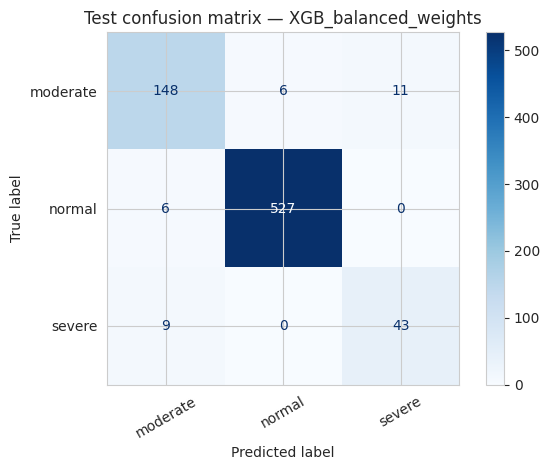

Saved plot: /content/ayurai_malnutrition_outputs/confusion_matrix_test.png
Test macro-F1 95% bootstrap CI: [0.864, 0.931]
Do not go back and re-tune using the test set.


In [30]:
# CELL 12.1 — FINAL TEST EVALUATION (first and only look at the test set)
require(["FINAL_MODEL", "FEATS_SEL", "SELECTED", "X_te", "y_te", "CLASSES", "K", "RANDOM_STATE", "RULE_DERIVED_SUSPECTED",
         "metrics_dict", "np", "pd", "plt", "save_fig", "confusion_matrix", "classification_report", "ConfusionMatrixDisplay", "f1_score"])

pred_te = FINAL_MODEL.predict(X_te[FEATS_SEL]); proba_te = FINAL_MODEL.predict_proba(X_te[FEATS_SEL])
TEST_METRICS = metrics_dict(y_te, pred_te, proba_te)
print("TEST metrics —", SELECTED); print(pd.Series(TEST_METRICS).round(4))
print("\n", classification_report(y_te, pred_te, target_names=CLASSES, zero_division=0))
cm = confusion_matrix(y_te, pred_te, labels=range(K))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", xticks_rotation=30)
plt.title(f"Test confusion matrix — {SELECTED}"); save_fig("confusion_matrix_test.png")

rng = np.random.RandomState(RANDOM_STATE); boots = []
for _ in range(300):
    ix = rng.randint(0, len(y_te), len(y_te)); boots.append(f1_score(y_te[ix], pred_te[ix], average="macro", zero_division=0))
TEST_CI = (float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5)))
print(f"Test macro-F1 95% bootstrap CI: [{TEST_CI[0]:.3f}, {TEST_CI[1]:.3f}]")
if RULE_DERIVED_SUSPECTED:
    print("\n⚠ INTERPRETATION: the label appears rule-derived from the measurements. These scores show how well the model reproduces "
          "that labelling rule; they are NOT evidence of independent medical prediction.")
print("Do not go back and re-tune using the test set.")

In [31]:
# CELL 13.1 — Error analysis on the test set
require(["X_te", "X_tr", "y_te", "pred_te", "proba_te", "CLASSES", "FEATURES", "NORMAL_IDX", "OUTPUT_DIR", "np", "pd", "os"])

te = X_te.copy()
te["y_true"] = [CLASSES[i] for i in y_te]; te["y_pred"] = [CLASSES[i] for i in pred_te]
te["confidence"] = proba_te.max(axis=1); te["error"] = (y_te != pred_te); te["any_missing"] = X_te.isna().any(axis=1)
mu, sd = X_tr.mean(), X_tr.std().replace(0, np.nan)
te["unusual_value"] = ((X_te - mu).abs() / sd > 3).any(axis=1)          # |z|>3 vs TRAIN statistics

print(f"Errors: {int(te.error.sum())} / {len(te)} = {100*te.error.mean():.1f}%")
print("\nPer-class error rate:"); display(te.groupby("y_true").error.agg(["mean", "sum", "count"]).round(3))
te["age_band"] = pd.qcut(te["age_months"], 4, duplicates="drop")
print("Error rate by age quartile:"); display(te.groupby("age_band").error.agg(["mean", "count"]).round(3))
print("Error rate by missing values:"); display(te.groupby("any_missing").error.agg(["mean", "count"]).round(3))
print("Error rate by unusual values (|z|>3):"); display(te.groupby("unusual_value").error.agg(["mean", "count"]).round(3))
print("Feature means, correct vs wrong:"); display(te.groupby("error")[FEATURES].mean().round(2))
print("Most frequent confusions:"); display(te[te.error].groupby(["y_true", "y_pred"]).size().sort_values(ascending=False).head(10))
print("Sex is not in Dataset A, so sex-based error analysis is not possible.")

if NORMAL_IDX:
    normal_names = [CLASSES[i] for i in NORMAL_IDX]
    fn = te[(~te.y_true.isin(normal_names)) & (te.y_pred.isin(normal_names))]
    fp = te[(te.y_true.isin(normal_names)) & (~te.y_pred.isin(normal_names))]
    print(f"\nFALSE NEGATIVES (at-risk predicted as normal) = {len(fn)}  ← most important for screening")
    display(fn.sort_values("confidence", ascending=False).head(10).round(2))
    print(f"FALSE POSITIVES (normal flagged at-risk) = {len(fp)}"); display(fp.head(10).round(2))
print("Examples of misclassified rows:"); display(te[te.error].head(10).round(2))
te.to_csv(os.path.join(OUTPUT_DIR, "test_error_analysis.csv"))

Errors: 32 / 750 = 4.3%

Per-class error rate:


,mean,sum,count
y_true,,,
moderate,0.103,17,165
normal,0.011,6,533
severe,0.173,9,52


Error rate by age quartile:


,mean,count
age_band,,
"(1.1300000000000001, 13.605]",0.085,188
"(13.605, 29.586]",0.075,187
"(29.586, 44.019]",0.005,187
"(44.019, 59.802]",0.005,188


Error rate by missing values:


...

,age_months,weight_kg,height_cm,muac_cm,bmi
error,,,,,
False,30.23,5.28,75.11,13.50,10.0
True,13.80,3.23,57.77,12.31,10.0


Most frequent confusions:


,,0
y_true,y_pred,
moderate,severe,11
severe,moderate,9
moderate,normal,6
normal,moderate,6


Sex is not in Dataset A, so sex-based error analysis is not possible.
Examples of misclassified rows:


,age_months,weight_kg,height_cm,muac_cm,bmi,y_true,y_pred,confidence,error,any_missing,unusual_value,age_band
237,9.62,3.0,57.03,11.82,10.0,moderate,severe,0.62,True,False,False,"(1.1300000000000001, 13.605]"
1200,17.63,3.0,60.84,13.51,10.0,moderate,normal,0.86,True,False,False,"(13.605, 29.586]"
3381,1.26,3.0,47.67,12.17,10.0,moderate,severe,0.62,True,False,False,"(1.1300000000000001, 13.605]"
2753,7.66,3.0,53.40,11.92,10.0,severe,moderate,0.60,True,False,False,"(1.1300000000000001, 13.605]"
3957,8.68,3.0,52.28,11.14,10.0,moderate,severe,0.78,True,False,False,"(1.1300000000000001, 13.605]"
2126,15.78,3.0,59.86,11.63,10.0,moderate,severe,0.98,True,False,False,"(13.605, 29.586]"
3109,12.53,3.0,61.35,13.49,10.0,moderate,normal,0.98,True,False,False,"(1.1300000000000001, 13.605]"
2751,15.88,3.0,63.81,13.25,10.0,moderate,normal,0.95,True,False,False,"(13.605, 29.586]"
2442,3.68,3.0,48.84,11.76,10.0,moderate,severe,0.96,True,False,False,"(1.1300000000000001, 13.605]"
2253,17.77,3.0,61.61,11.73,10.0,moderate,severe,0.86,True,False,False,"(13.605, 29.586]"


ExactExplainer explainer: 301it [00:32,  9.25it/s]


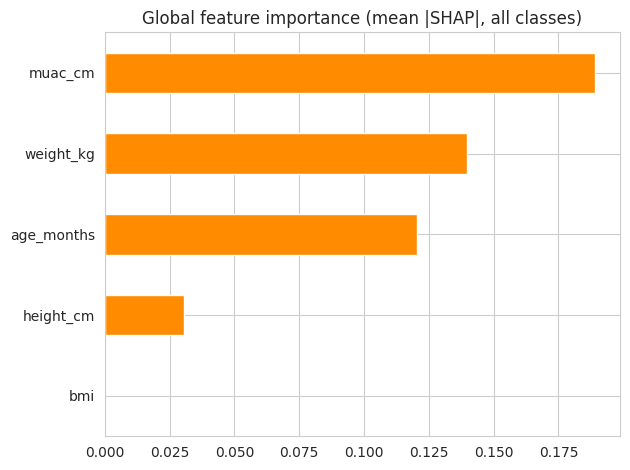

Saved plot: /content/ayurai_malnutrition_outputs/shap_global_importance.png


,moderate,normal,severe
age_months,0.0886,0.1369,0.1357
weight_kg,0.1204,0.1773,0.1210
height_cm,0.0393,0.0128,0.0396
muac_cm,0.1967,0.2807,0.0904
bmi,0.0000,0.0000,0.0000


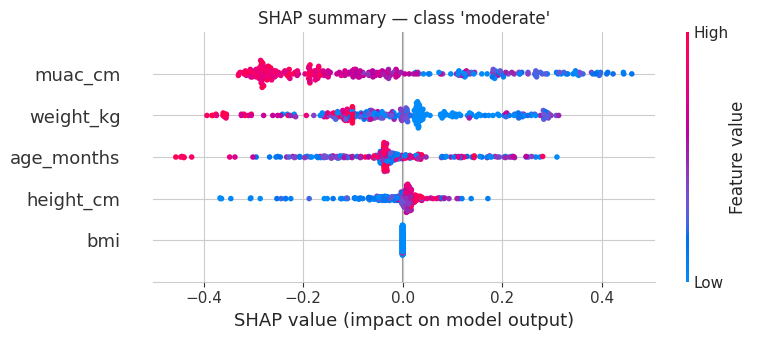

Saved plot: /content/ayurai_malnutrition_outputs/shap_summary.png


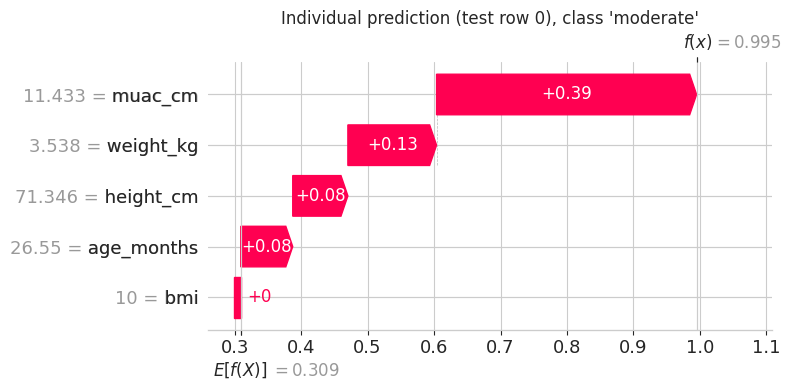

Saved plot: /content/ayurai_malnutrition_outputs/shap_individual.png

The model used these features most strongly in its predictions. SHAP describes model behaviour, not medical causation.


In [32]:
# CELL 14.1 — SHAP (model-agnostic; only 5 features so it is fast)
require(["FINAL_MODEL", "FEATS_SEL", "X_tr", "X_te", "CLASSES", "RISK_IDX", "RANDOM_STATE", "np", "pd", "plt", "shap", "save_fig"])

prep = FINAL_MODEL.named_steps["prep"]; clf = FINAL_MODEL.named_steps["clf"]
Xtr_p = prep.transform(X_tr[FEATS_SEL]); N_EXPLAIN = min(300, len(X_te))
Xte_p = prep.transform(X_te[FEATS_SEL])[:N_EXPLAIN]
bg = shap.sample(Xtr_p, min(100, len(Xtr_p)), random_state=RANDOM_STATE)
try:
    expl = shap.Explainer(clf.predict_proba, shap.maskers.Independent(bg), feature_names=FEATS_SEL)
    sv = expl(Xte_p)
    vals = sv.values if sv.values.ndim == 3 else sv.values[:, :, None]
    imp = pd.Series(np.abs(vals).mean(axis=(0, 2)), index=FEATS_SEL).sort_values()
    imp.plot.barh(color="darkorange"); plt.title("Global feature importance (mean |SHAP|, all classes)"); save_fig("shap_global_importance.png")
    per_class = pd.DataFrame(np.abs(vals).mean(axis=0), index=FEATS_SEL, columns=CLASSES[:vals.shape[2]]); display(per_class.round(4))
    cls = RISK_IDX[0] if RISK_IDX else 0
    shap.summary_plot(vals[:, :, cls], X_te[FEATS_SEL].iloc[:N_EXPLAIN].values, feature_names=FEATS_SEL, show=False)
    plt.title(f"SHAP summary — class '{CLASSES[cls]}'"); save_fig("shap_summary.png")
    try:   # individual explanation, shown in original units
        sv.data = X_te[FEATS_SEL].iloc[:N_EXPLAIN].values
        shap.plots.waterfall(sv[0, :, cls], show=False); plt.title(f"Individual prediction (test row 0), class '{CLASSES[cls]}'"); save_fig("shap_individual.png")
    except Exception as e:
        print("Individual waterfall skipped:", e)
    print("\nThe model used these features most strongly in its predictions. SHAP describes model behaviour, not medical causation.")
except Exception as e:
    from sklearn.inspection import permutation_importance
    print("SHAP failed (", e, ") — using permutation importance instead.")
    pi = permutation_importance(FINAL_MODEL, X_te[FEATS_SEL], y_te, n_repeats=10, random_state=RANDOM_STATE, scoring="f1_macro")
    print(pd.Series(pi.importances_mean, index=FEATS_SEL).sort_values(ascending=False))

In [33]:
# CELL 15.1 — Save artifacts
require(["FINAL_MODEL", "FEATS_SEL", "SELECTED", "le", "CLASSES", "NORMAL_IDX", "VAL_METRICS", "TEST_METRICS", "TEST_CI", "OUTPUT_DIR",
         "PATH_A", "dfA_raw", "dfA_model", "X_tr", "X_va", "X_te", "RANDOM_STATE", "LEAK_SCORES", "RULE_DERIVED_SUSPECTED", "BMI_DERIVED",
         "joblib", "json", "os", "np", "datetime"])
import shutil

def _clean(d): return {k: (None if (isinstance(v, float) and np.isnan(v)) else float(v)) for k, v in d.items()}
joblib.dump(FINAL_MODEL.named_steps["clf"], os.path.join(OUTPUT_DIR, "malnutrition_model.joblib"))
joblib.dump(FINAL_MODEL.named_steps["prep"], os.path.join(OUTPUT_DIR, "preprocessor.joblib"))
joblib.dump(FINAL_MODEL, os.path.join(OUTPUT_DIR, "full_pipeline.joblib"))
joblib.dump(le, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))
json.dump(FEATS_SEL, open(os.path.join(OUTPUT_DIR, "feature_columns.json"), "w"))
json.dump({int(i): c for i, c in enumerate(CLASSES)}, open(os.path.join(OUTPUT_DIR, "label_mapping.json"), "w"), indent=2)
json.dump({"validation": _clean(VAL_METRICS), "test": _clean(TEST_METRICS), "test_macroF1_95CI": list(TEST_CI)},
          open(os.path.join(OUTPUT_DIR, "metrics.json"), "w"), indent=2)

metadata = {
    "project": "AyurAI nutrition-risk screening module (screening support, NOT a diagnosis)",
    "training_date": datetime.datetime.now().isoformat(timespec="seconds"),
    "training_dataset": os.path.basename(PATH_A), "rows_original": int(len(dfA_raw)), "rows_used": int(len(dfA_model)),
    "split": {"train": int(len(X_tr)), "validation": int(len(X_va)), "test": int(len(X_te)), "random_state": RANDOM_STATE},
    "target": "nutrition_status_clean (case/space-normalised copy of nutrition_status_original)", "class_names": CLASSES,
    "normal_class": [CLASSES[i] for i in NORMAL_IDX] if NORMAL_IDX else None, "features": FEATS_SEL,
    "feature_training_ranges": {c: [float(dfA_model[c].min()), float(dfA_model[c].max())] for c in FEATS_SEL},
    "preprocessing": "median imputation + standard scaling fitted on training split only; exact duplicates removed; non-positive measurements set to NaN",
    "model_type": type(FINAL_MODEL.named_steps["clf"]).__name__, "selected_model_name": SELECTED,
    "validation_metrics": _clean(VAL_METRICS), "test_metrics": _clean(TEST_METRICS),
    "leakage_findings": {"bmi_derived_from_weight_height": bool(BMI_DERIVED), "label_likely_rule_derived": bool(RULE_DERIVED_SUSPECTED),
                         "shallow_tree_cv_accuracy": LEAK_SCORES},
    "known_limitations": [
        "Screening/risk-support only; not a diagnosis and not clinically validated.",
        "Check the age audit: if Dataset A is mainly under-5, school-age performance is unverified.",
        "The label may be derived from the same measurements, so metrics may reflect rule reproduction.",
        "No subject ID: repeat records of the same child cannot be excluded beyond exact duplicates.",
        "Jaipur is used for external validation only if the compatibility checks in Cell 17.1 pass."]}
json.dump(metadata, open(os.path.join(OUTPUT_DIR, "model_metadata.json"), "w"), indent=2, default=str)
shutil.make_archive("/content/ayurai_malnutrition_outputs", "zip", OUTPUT_DIR)
print("Saved files:", sorted(os.listdir(OUTPUT_DIR)))
print("Zip created: /content/ayurai_malnutrition_outputs.zip (download from the Files sidebar; Google Drive is not used).")

Saved files: ['A_age_distribution.png', 'A_clean_full.csv', 'A_modelling_frame.csv', 'ablation_validation.csv', 'confusion_matrix_test.png', 'data_dictionary_A.csv', 'data_dictionary_B_jaipur.csv', 'eda_boxplots.png', 'eda_class_age.png', 'eda_correlation.png', 'feature_columns.json', 'full_pipeline.joblib', 'label_encoder.joblib', 'label_mapping.json', 'malnutrition_model.joblib', 'metrics.json', 'model_metadata.json', 'preprocessor.joblib', 'shap_global_importance.png', 'shap_individual.png', 'shap_summary.png', 'split_indices.json', 'test_error_analysis.csv', 'validation_results.csv']
Zip created: /content/ayurai_malnutrition_outputs.zip (download from the Files sidebar; Google Drive is not used).


In [34]:
# CELL 16.1 — Reproducible prediction function (loads the SAVED artifacts)
require(["OUTPUT_DIR", "joblib", "json", "os", "np", "pd", "X_te"])

_clf = joblib.load(os.path.join(OUTPUT_DIR, "malnutrition_model.joblib"))
_prep = joblib.load(os.path.join(OUTPUT_DIR, "preprocessor.joblib"))
_le = joblib.load(os.path.join(OUTPUT_DIR, "label_encoder.joblib"))
_feats = json.load(open(os.path.join(OUTPUT_DIR, "feature_columns.json")))
_meta = json.load(open(os.path.join(OUTPUT_DIR, "model_metadata.json")))
_normal = set(_meta.get("normal_class") or [])

def predict_malnutrition(age, weight, height, muac, bmi=None):
    """Nutrition-RISK screening support. age in MONTHS; weight kg; height cm; muac cm. Not a diagnosis."""
    for n, v in {"age": age, "weight": weight, "height": height, "muac": muac}.items():
        if v is None or not np.isfinite(float(v)) or float(v) <= 0:
            raise ValueError(f"Invalid {n}: {v}")
    if bmi is None:
        bmi = weight / (height / 100) ** 2
    row = pd.DataFrame([{"age_months": age, "weight_kg": weight, "height_cm": height, "muac_cm": muac, "bmi": bmi}])[_feats]
    proba = _clf.predict_proba(_prep.transform(row))[0]
    idx = int(np.argmax(proba)); cls = str(_le.classes_[idx])
    warns = [f"{c}={float(row[c].iloc[0]):.1f} is outside the training range {lo:.1f}–{hi:.1f}"
             for c, (lo, hi) in _meta["feature_training_ranges"].items() if not lo <= float(row[c].iloc[0]) <= hi]
    if _normal:
        elevated = cls not in _normal
        msg = ("The model predicts elevated nutrition risk and recommends further assessment by a qualified health professional."
               if elevated else "The model does not predict elevated nutrition risk from these measurements. This is not a clearance; routine monitoring still applies.")
    else:
        elevated = None
        msg = "The predicted category is shown for screening support only; further assessment by a health professional is recommended."
    if warns:
        msg += " Inputs are outside the training population; interpret with extra caution."
    return {"predicted_class": cls, "probabilities": {str(c): float(p) for c, p in zip(_le.classes_, proba)},
            "elevated_risk": elevated, "support_message": msg, "input_warnings": warns,
            "disclaimer": "AI-assisted screening only; not a medical diagnosis."}

r = X_te.dropna().iloc[0]
print(json.dumps(predict_malnutrition(r.age_months, r.weight_kg, r.height_cm, r.muac_cm, r.bmi), indent=2))
print("\nOut-of-range test:"); print(json.dumps(predict_malnutrition(168, 40, 150, 22), indent=2))

{
  "predicted_class": "moderate",
  "probabilities": {
    "moderate": 0.9950385689735413,
    "normal": 0.0001797928416635841,
    "severe": 0.004781580530107021
  },
  "elevated_risk": null,
  "support_message": "The predicted category is shown for screening support only; further assessment by a health professional is recommended.",
  "input_warnings": [],
  "disclaimer": "AI-assisted screening only; not a medical diagnosis."
}

Out-of-range test:
{
  "predicted_class": "normal",
  "probabilities": {
    "moderate": 9.303304250352085e-05,
    "normal": 0.9998843669891357,
    "severe": 2.259567190776579e-05
  },
  "elevated_risk": null,
  "support_message": "The predicted category is shown for screening support only; further assessment by a health professional is recommended. Inputs are outside the training population; interpret with extra caution.",
  "input_warnings": [
    "age_months=168.0 is outside the training range 1.0\u201360.0",
    "weight_kg=40.0 is outside the training 

In [35]:
# CELL 17.1 — Is Jaipur genuinely usable for EXTERNAL VALIDATION of the Dataset A model?
require(["dfB_raw", "B_PRESENT", "dfA_model", "CLASSES", "FEATS_SEL", "OUTPUT_DIR", "np", "pd", "re", "os"])

muac_like = [c for c in dfB_raw.columns if re.search(r"muac|arm.?circ|midupper", str(c).lower())]
age_col = B_PRESENT.get("de_age")
age_vals = pd.to_numeric(dfB_raw[age_col], errors="coerce") if age_col else pd.Series(dtype=float)
age_categorical = (age_col is None) or (age_vals.nunique() <= 12)
print("de_age unique values:", sorted(age_vals.dropna().unique())[:15], "| treated as category codes:", age_categorical)
print("de_grade values:", dfB_raw[B_PRESENT["de_grade"]].value_counts(dropna=False).sort_index().to_dict() if "de_grade" in B_PRESENT else "absent")

target_cols = [B_PRESENT[c] for c in ["db_underwt", "db_overwt", "db_obese"] if c in B_PRESENT]
b_labels = set()
for c in target_cols:
    b_labels |= set(dfB_raw[c].dropna().astype(str).str.strip().str.lower().unique())
vocab_overlap = set(c.lower() for c in CLASSES) & b_labels
a_p99_years = float(dfA_model["age_months"].quantile(0.99) / 12)

checks = {
    "All model features available (MUAC present in Jaipur)": ("muac_cm" not in FEATS_SEL) or bool(muac_like),
    "Age in months/years derivable (not category codes)": not age_categorical,
    "Height and weight present": all(k in B_PRESENT for k in ["db_height", "db_weight"]),
    "Target classes comparable (shared label vocabulary with Dataset A)": bool(vocab_overlap),
    "Age populations overlap (Dataset A 99th pct age ≥ 10y)": a_p99_years >= 10,
}
print(f"\nDataset A 99th-percentile age: {a_p99_years:.1f} years")
print("MUAC-like columns in Jaipur:", muac_like)
print("Jaipur label values:", sorted(b_labels)[:15], "| overlap with Dataset A classes:", vocab_overlap or "none")
print()
for k, v in checks.items(): print(("PASS  " if v else "FAIL  ") + k)
EXTERNAL_VALID = all(checks.values())
print("\nSCIENTIFICALLY VALID EXTERNAL VALIDATION POSSIBLE:", EXTERNAL_VALID)
if not EXTERNAL_VALID:
    print("→ I will NOT force Jaipur onto the Dataset A model. Jaipur is used only for supporting population analysis (Cell 17.2).")
else:
    print("→ All automatic checks passed, but label definitions must still be confirmed from the GSHS codebook. "
          "Send me this output and I will write the explicit variable mapping cell; no retraining on Jaipur.")
pd.DataFrame({"check": list(checks), "passed": list(checks.values())}).to_csv(os.path.join(OUTPUT_DIR, "jaipur_compatibility.csv"), index=False)

de_age unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)] | treated as category codes: True
de_grade values: {1.0: 808, 2.0: 746, 3.0: 818, 4.0: 820, 5.0: 531, 6.0: 549, nan: 27}

Dataset A 99th-percentile age: 5.0 years
MUAC-like columns in Jaipur: []
Jaipur label values: ['1.0', '2.0'] | overlap with Dataset A classes: none

FAIL  All model features available (MUAC present in Jaipur)
FAIL  Age in months/years derivable (not category codes)
PASS  Height and weight present
FAIL  Target classes comparable (shared label vocabulary with Dataset A)
FAIL  Age populations overlap (Dataset A 99th pct age ≥ 10y)

SCIENTIFICALLY VALID EXTERNAL VALIDATION POSSIBLE: False
→ I will NOT force Jaipur onto the Dataset A model. Jaipur is used only for supporting population analysis (Cell 17.2).


Height median=157.00 → unit: cm | weight median=46.0
Computed BMI: n=4294, median=18.0, p1=12.7, p99=30.5


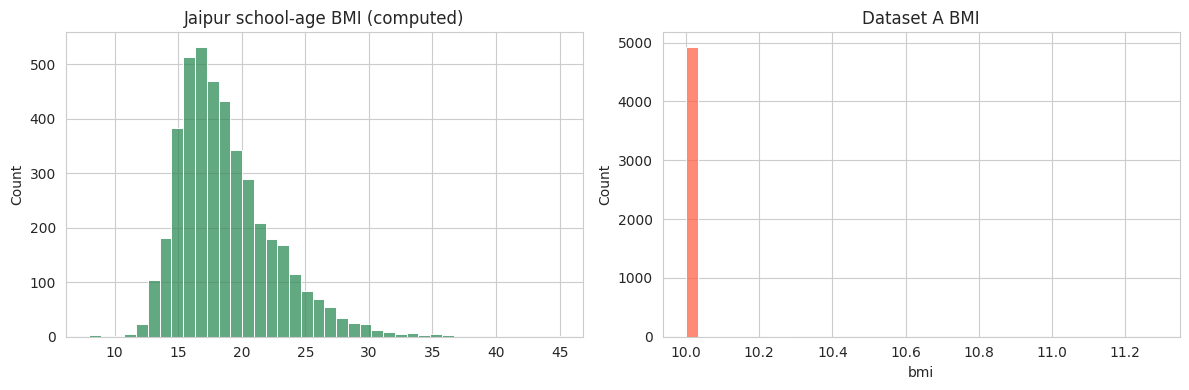

Saved plot: /content/ayurai_malnutrition_outputs/population_comparison_A_vs_Jaipur.png

db_underwt: distribution (incl. missing)
db_underwt
2.0    0.776
1.0    0.205
NaN    0.019
Name: proportion, dtype: float64
db_underwt    1.0    2.0
de_sex                  
1.0         0.252  0.748
2.0         0.160  0.840
Computed BMI median by indicator value:
db_underwt
1.0    14.98
2.0    18.97
dtype: float64

db_overwt: distribution (incl. missing)
db_overwt
2.0    0.846
1.0    0.135
NaN    0.019
Name: proportion, dtype: float64
db_overwt    1.0    2.0
de_sex                 
1.0        0.148  0.852
2.0        0.125  0.875
Computed BMI median by indicator value:
db_overwt
1.0    25.06
2.0    17.47
dtype: float64

db_obese: distribution (incl. missing)
db_obese
2.0    0.946
1.0    0.034
NaN    0.019
Name: proportion, dtype: float64
db_obese    1.0    2.0
de_sex                
1.0       0.036  0.964
2.0       0.034  0.966
Computed BMI median by indicator value:
db_obese
1.0    29.07
2.0    17.8

In [36]:
# CELL 17.2 — Supporting analysis of Jaipur (no model applied, no retraining, no merge)
require(["dfB_raw", "B_PRESENT", "dfA_model", "EXTERNAL_VALID", "OUTPUT_DIR", "np", "pd", "plt", "sns", "save_fig", "os"])

def bnum(key):
    return pd.to_numeric(dfB_raw[B_PRESENT[key]], errors="coerce") if key in B_PRESENT else pd.Series(np.nan, index=dfB_raw.index)
h, w = bnum("db_height"), bnum("db_weight")
hmed = h.dropna().median()
if hmed < 3:     h_cm, unit = h * 100, "metres → converted to cm"
elif 30 <= hmed <= 250: h_cm, unit = h, "cm"
else:            h_cm, unit = pd.Series(np.nan, index=h.index), "UNKNOWN (BMI not computed)"
print(f"Height median={hmed:.2f} → unit: {unit} | weight median={w.dropna().median():.1f}")
bmi_B = (w / (h_cm / 100) ** 2).replace([np.inf, -np.inf], np.nan)
print(f"Computed BMI: n={bmi_B.notna().sum()}, median={bmi_B.median():.1f}, p1={bmi_B.quantile(.01):.1f}, p99={bmi_B.quantile(.99):.1f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(bmi_B.dropna().clip(8, 45), bins=40, ax=ax[0], color="seagreen"); ax[0].set_title("Jaipur school-age BMI (computed)")
sns.histplot(dfA_model["bmi"].dropna().clip(8, 45), bins=40, ax=ax[1], color="tomato"); ax[1].set_title("Dataset A BMI")
save_fig("population_comparison_A_vs_Jaipur.png")

summary = {}
for key in ["db_underwt", "db_overwt", "db_obese"]:
    if key in B_PRESENT:
        col = B_PRESENT[key]
        print(f"\n{key}: distribution (incl. missing)"); print(dfB_raw[col].value_counts(normalize=True, dropna=False).round(3))
        summary[key] = dfB_raw[col].value_counts(dropna=False).to_dict()
        if "de_sex" in B_PRESENT:
            print(pd.crosstab(dfB_raw[B_PRESENT["de_sex"]], dfB_raw[col], normalize="index").round(3))
        print("Computed BMI median by indicator value:"); print(bmi_B.groupby(dfB_raw[col]).median().round(2))

for key in ["db_hungry", "db_fruit", "db_veg", "db_soda", "db_ssb", "db_fat", "db_sugar"]:
    if key in B_PRESENT:
        print(f"\n{key}:", dfB_raw[B_PRESENT[key]].value_counts(dropna=False).sort_index().to_dict())
if "de_sex" in B_PRESENT: print("\nSex:", dfB_raw[B_PRESENT["de_sex"]].value_counts(dropna=False).to_dict())

pd.Series({"bmi_median": bmi_B.median(), "n_bmi": int(bmi_B.notna().sum()), "external_valid": EXTERNAL_VALID}).to_csv(os.path.join(OUTPUT_DIR, "jaipur_supporting_summary.csv"))
print("\nJaipur analysis complete. External validation performed:", EXTERNAL_VALID is True and "only after manual mapping" or "NO (checks failed)")

In [37]:
# CELL BMI-1 — Raw BMI distribution (READ-ONLY; no data is modified)
import os, re, numpy as np, pandas as pd

PATH_A = "/content/malnutrition_data (1).csv"
OUTPUT_ROOT = "/content/ayurai_malnutrition_outputs"
BMI_DIR = os.path.join(OUTPUT_ROOT, "bmi_investigation")
for sub in ["original_model", "bmi_investigation", "corrected_model", "jaipur_validation"]:
    os.makedirs(os.path.join(OUTPUT_ROOT, sub), exist_ok=True)

# --- Load raw Dataset A fresh from disk (does not rely on earlier cells) ---
if not os.path.exists(PATH_A):
    raise FileNotFoundError(f"{PATH_A} not found. Upload it to /content first.")
dfA_raw = pd.read_csv(PATH_A, low_memory=False)
dfA_raw_text = pd.read_csv(PATH_A, dtype=str, low_memory=False)      # exact text as written in the file
print("Dataset A raw shape:", dfA_raw.shape)

# --- Resolve actual column names (no assumption) ---
lower = {str(c).strip().lower(): c for c in dfA_raw.columns}
needed = ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi", "nutrition_status"]
missing_cols = [c for c in needed if c not in lower]
if missing_cols:
    print("Actual columns:", list(dfA_raw.columns))
    raise RuntimeError(f"Missing expected columns: {missing_cols}")
C = {k: lower[k] for k in needed}
bmi = pd.to_numeric(dfA_raw[C["bmi"]], errors="coerce")
bmi_txt = dfA_raw_text[C["bmi"]]

print("\n" + "=" * 70); print("1. BASIC BMI STATISTICS"); print("=" * 70)
print("dtype in file          :", dfA_raw[C["bmi"]].dtype)
print("rows                   :", len(bmi))
print("missing (NaN)          :", int(bmi.isna().sum()))
print("non-numeric text values:", int((bmi.isna() & dfA_raw[C["bmi"]].notna()).sum()))
print("unique values          :", bmi.nunique())
print(f"min / median / max     : {bmi.min():.6f} / {bmi.median():.6f} / {bmi.max():.6f}")
print(f"mean / std             : {bmi.mean():.6f} / {bmi.std():.6f}")
q = bmi.quantile([0, .01, .05, .10, .25, .50, .75, .90, .95, .99, 1.0])
print("\nQuantiles:"); print(q.round(6).to_string())

print("\n" + "=" * 70); print("2. HOW MUCH IS EXACTLY 10?"); print("=" * 70)
n_valid = int(bmi.notna().sum())
exact10 = int((bmi == 10.0).sum())
near10 = int(np.isclose(bmi, 10.0, atol=1e-6).sum())
within_001 = int((bmi.sub(10.0).abs() <= 0.01).sum())
print(f"== 10.0 exactly            : {exact10} / {n_valid} = {100*exact10/n_valid:.2f}%")
print(f"within 1e-6 of 10.0       : {near10} / {n_valid} = {100*near10/n_valid:.2f}%")
print(f"within 0.01 of 10.0       : {within_001} / {n_valid} = {100*within_001/n_valid:.2f}%")
print(f"below 10.0                : {int((bmi < 10).sum())}")
print(f"above 10.0                : {int((bmi > 10).sum())}")

print("\n" + "=" * 70); print("3. FREQUENCY OF EACH BMI VALUE (top 25)"); print("=" * 70)
vc = bmi.value_counts(dropna=False).rename_axis("bmi_value").reset_index(name="count")
vc["percent"] = (100 * vc["count"] / len(bmi)).round(3)
print(vc.head(25).to_string(index=False))
print(f"\n... {len(vc)} distinct values in total. Values other than 10.0:")
other = vc[vc.bmi_value != 10.0]
print(f"   count of rows with bmi != 10.0 : {int(other['count'].sum())}")
print(f"   range of those values          : {other.bmi_value.min():.6f} – {other.bmi_value.max():.6f}")
vc.to_csv(os.path.join(BMI_DIR, "bmi_value_counts.csv"), index=False)

print("\n" + "=" * 70); print("4. HOW BMI IS WRITTEN IN THE CSV FILE (raw text, no parsing)"); print("=" * 70)
txt_vc = bmi_txt.value_counts(dropna=False).head(10)
print("Most common raw strings:"); print(txt_vc.to_string())
decimals = bmi_txt.dropna().str.extract(r"\.(\d+)")[0].str.len()
print("\nNumber of decimal places written (distribution):"); print(decimals.value_counts(dropna=False).sort_index().to_string())

print("\n" + "=" * 70); print("5. DO BMI=10 ROWS DIFFER FROM THE OTHER ROWS?"); print("=" * 70)
is10 = (bmi == 10.0)
num_cols = [C["age_months"], C["weight_kg"], C["height_cm"], C["muac_cm"]]
comp = dfA_raw[num_cols].apply(pd.to_numeric, errors="coerce").groupby(is10.rename("bmi_is_exactly_10")).agg(["count", "min", "median", "max"]).round(2)
print(comp.T.to_string())
print("\nnutrition_status counts by (bmi == 10.0):")
print(pd.crosstab(dfA_raw[C["nutrition_status"]].astype(str).str.strip(), is10.rename("bmi_is_exactly_10"), margins=True).to_string())

print("\n" + "=" * 70); print("6. RANDOM ROWS (random_state=42)"); print("=" * 70)
cols_show = [C[k] for k in ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi", "nutrition_status"]]
print("--- 10 random rows with bmi == 10.0 ---")
print(dfA_raw.loc[is10, cols_show].sample(min(10, int(is10.sum())), random_state=42).to_string())
print("\n--- up to 10 random rows with bmi != 10.0 ---")
print(dfA_raw.loc[~is10 & bmi.notna(), cols_show].sample(min(10, int((~is10 & bmi.notna()).sum())), random_state=42).to_string())

print("\nBMI-1 complete. dfA_raw was not modified. Value counts saved to:", os.path.join(BMI_DIR, "bmi_value_counts.csv"))
print("This cell makes NO statement about why 10.0 occurs; that requires BMI-2 and BMI-3.")

Dataset A raw shape: (5000, 6)

1. BASIC BMI STATISTICS
dtype in file          : float64
rows                   : 5000
missing (NaN)          : 0
non-numeric text values: 0
unique values          : 83
min / median / max     : 10.000000 / 10.000000 / 11.285436
mean / std             : 10.004274 / 0.047272

Quantiles:
0.00    10.000000
0.01    10.000000
0.05    10.000000
0.10    10.000000
0.25    10.000000
0.50    10.000000
0.75    10.000000
0.90    10.000000
0.95    10.000000
0.99    10.125295
1.00    11.285436

2. HOW MUCH IS EXACTLY 10?
== 10.0 exactly            : 4918 / 5000 = 98.36%
within 1e-6 of 10.0       : 4918 / 5000 = 98.36%
within 0.01 of 10.0       : 4922 / 5000 = 98.44%
below 10.0                : 0
above 10.0                : 82

3. FREQUENCY OF EACH BMI VALUE (top 25)
 bmi_value  count  percent
 10.000000   4918    98.36
 10.250571      1     0.02
 10.244968      1     0.02
 10.277086      1     0.02
 10.551637      1     0.02
 10.083595      1     0.02
 10.303925      1

In [38]:
# CELL BMI-2 — Independent BMI Consistency Check
# READ-ONLY on the raw data. No retraining. No BMI decision is made here.

import os, numpy as np, pandas as pd

PATH_A = "/content/malnutrition_data (1).csv"
OUTPUT_ROOT = "/content/ayurai_malnutrition_outputs"
BMI_DIR = os.path.join(OUTPUT_ROOT, "bmi_investigation")
os.makedirs(BMI_DIR, exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

# ---------- 1. Load fresh and verify required columns ----------
if not os.path.exists(PATH_A):
    raise FileNotFoundError(f"{PATH_A} not found. Upload it to /content first.")
dfA_raw = pd.read_csv(PATH_A, low_memory=False)          # never modified below
lower = {str(c).strip().lower(): c for c in dfA_raw.columns}
required = ["age_months", "weight_kg", "height_cm", "bmi", "nutrition_status"]
missing = [c for c in required if c not in lower]
if missing:
    print("Actual columns:", list(dfA_raw.columns))
    raise RuntimeError(f"Required columns missing from Dataset A: {missing}. Stopping.")
C = {k: lower[k] for k in required}
print("Dataset A shape:", dfA_raw.shape)
print("Column mapping :", C)

# Diagnostic COPY (dfA_raw is not touched)
diag = pd.DataFrame({
    "row_index": dfA_raw.index,
    "age_months": pd.to_numeric(dfA_raw[C["age_months"]], errors="coerce"),
    "weight_kg": pd.to_numeric(dfA_raw[C["weight_kg"]], errors="coerce"),
    "height_cm": pd.to_numeric(dfA_raw[C["height_cm"]], errors="coerce"),
    "bmi_original": pd.to_numeric(dfA_raw[C["bmi"]], errors="coerce"),
    "nutrition_status": dfA_raw[C["nutrition_status"]],
})
for c in ["age_months", "weight_kg", "height_cm", "bmi_original"]:
    n_bad = int(diag[c].isna().sum() - dfA_raw[C[{"bmi_original": "bmi"}.get(c, c)]].isna().sum())
    if n_bad:
        print(f"⚠ {c}: {n_bad} non-numeric values became NaN during numeric conversion")

# ---------- 2. Height and weight ranges (units NOT assumed) ----------
print("\n" + "=" * 70); print("2. HEIGHT AND WEIGHT RANGES"); print("=" * 70)
def rng(s):
    return pd.Series({"count": int(s.notna().sum()), "missing": int(s.isna().sum()), "min": s.min(), "p1": s.quantile(.01),
                      "median": s.median(), "p99": s.quantile(.99), "max": s.max()})
rng_tbl = pd.DataFrame({"weight_kg": rng(diag.weight_kg), "height_cm": rng(diag.height_cm)}).round(3)
print(rng_tbl.to_string())
print(f"\nNon-positive weights: {int((diag.weight_kg <= 0).sum())} | non-positive heights: {int((diag.height_cm <= 0).sum())}")

# ---------- 3. Unit plausibility check, then independent BMI ----------
print("\n" + "=" * 70); print("3. UNIT VERIFICATION"); print("=" * 70)
h_med, h_p1, h_p99 = diag.height_cm.median(), diag.height_cm.quantile(.01), diag.height_cm.quantile(.99)
w_med = diag.weight_kg.median()
print(f"height median={h_med:.2f}, p1={h_p1:.2f}, p99={h_p99:.2f}  | weight median={w_med:.2f}")
if h_med < 3:
    raise RuntimeError("Height values look like METRES (median < 3), not centimetres. "
                       "Calculation stopped; the (height/100) formula would be wrong. Send me this output.")
height_plausible_cm = (30 <= h_med <= 220) and (h_p1 >= 20) and (h_p99 <= 250)
weight_plausible_kg = (1 <= w_med <= 150)
print("Height values plausible as centimetres:", height_plausible_cm)
print("Weight values plausible as kilograms  :", weight_plausible_kg)
if not (height_plausible_cm and weight_plausible_kg):
    raise RuntimeError("Units could not be confirmed as cm / kg. Calculation stopped; send me this output.")
print("→ Units plausibly confirmed as cm and kg (plausibility only; the file has no unit documentation).")

valid_hw = (diag.height_cm > 0) & (diag.weight_kg > 0)
diag["bmi_calculated"] = np.where(valid_hw, diag.weight_kg / ((diag.height_cm / 100) ** 2), np.nan)
diag["bmi_difference"] = diag["bmi_original"] - diag["bmi_calculated"]       # original − calculated
diag["abs_difference"] = diag["bmi_difference"].abs()
print(f"Rows where BMI could be calculated: {int(diag.bmi_calculated.notna().sum())} / {len(diag)}")

# ---------- 4. Original vs calculated ----------
print("\n" + "=" * 70); print("4. ORIGINAL vs CALCULATED BMI (all rows)"); print("=" * 70)
both = diag.dropna(subset=["bmi_original", "bmi_calculated"])
ad = both.abs_difference
print(f"Calculated BMI  mean={both.bmi_calculated.mean():.3f} median={both.bmi_calculated.median():.3f} "
      f"min={both.bmi_calculated.min():.3f} max={both.bmi_calculated.max():.3f}")
print(f"Original BMI    mean={both.bmi_original.mean():.3f} median={both.bmi_original.median():.3f} "
      f"min={both.bmi_original.min():.3f} max={both.bmi_original.max():.3f}")
print(f"\nMean |difference|   : {ad.mean():.4f}")
print(f"Median |difference| : {ad.median():.4f}")
print(f"Max |difference|    : {ad.max():.4f}")
print(f"Rows |diff| <= 0.01 : {int((ad <= 0.01).sum())} / {len(both)}")
print(f"Rows |diff| >  0.1  : {int((ad > 0.1).sum())} / {len(both)}")
print(f"Rows |diff| >  1.0  : {int((ad > 1.0).sum())} / {len(both)}")
if both.bmi_original.nunique() > 1:
    print(f"Pearson correlation original vs calculated: {both[['bmi_original','bmi_calculated']].corr().iloc[0,1]:.4f}")

# ---------- 5. BMI == 10 rows ----------
print("\n" + "=" * 70); print("5. ROWS WHERE bmi_original == 10.0"); print("=" * 70)
is10 = both.bmi_original == 10.0
b10 = both[is10]
print(f"Rows: {len(b10)}")
cb = b10.bmi_calculated
print(f"Calculated BMI in these rows: min={cb.min():.3f} median={cb.median():.3f} max={cb.max():.3f} mean={cb.mean():.3f}")
print(f"Close to 10 (|calc − 10| <= 0.1)        : {int(((cb - 10).abs() <= 0.1).sum())}")
print(f"Moderately different (0.1 < |d| <= 1.0) : {int((((cb - 10).abs() > 0.1) & ((cb - 10).abs() <= 1.0)).sum())}")
print(f"Substantially different (|d| > 1.0)     : {int(((cb - 10).abs() > 1.0).sum())}")
print(f"Calculated BMI quantiles (BMI=10 rows):"); print(cb.quantile([.01, .05, .25, .5, .75, .95, .99]).round(3).to_string())
show = ["age_months", "weight_kg", "height_cm", "bmi_original", "bmi_calculated", "nutrition_status"]
print("\n10 representative rows with bmi_original == 10.0 (random_state=42):")
print(b10[show].sample(min(10, len(b10)), random_state=42).round(3).to_string())

# ---------- 6. BMI != 10 rows ----------
print("\n" + "=" * 70); print("6. ROWS WHERE bmi_original != 10.0"); print("=" * 70)
n10 = both[~is10]
print(f"Rows: {len(n10)}")
if len(n10):
    print(f"Calculated BMI in these rows: min={n10.bmi_calculated.min():.3f} median={n10.bmi_calculated.median():.3f} max={n10.bmi_calculated.max():.3f}")
    print(f"Mean |difference| in these rows: {n10.abs_difference.mean():.4f}; rows |diff| <= 0.01: {int((n10.abs_difference <= 0.01).sum())}")
    print("\nUp to 10 representative rows with bmi_original != 10.0 (random_state=42):")
    print(n10[show].sample(min(10, len(n10)), random_state=42).round(3).to_string())

# ---------- 7. Save ONLY the diagnostic comparison ----------
out_path = os.path.join(BMI_DIR, "bmi_consistency_check.csv")
diag.drop(columns=["abs_difference"]).to_csv(out_path, index=False)
print("\nSaved diagnostic comparison:", out_path)

print("\nBMI-2 complete.")
print("Raw dataset unchanged.")
print("No model retrained.")
print("No BMI decision made yet.")

Dataset A shape: (5000, 6)
Column mapping : {'age_months': 'age_months', 'weight_kg': 'weight_kg', 'height_cm': 'height_cm', 'bmi': 'bmi', 'nutrition_status': 'nutrition_status'}

2. HEIGHT AND WEIGHT RANGES
         weight_kg  height_cm
count     5000.000   5000.000
missing      0.000      0.000
min          3.000     45.000
p1           3.000     45.272
median       4.649     75.010
p99         10.377    105.000
max         10.727    105.000

Non-positive weights: 0 | non-positive heights: 0

3. UNIT VERIFICATION
height median=75.01, p1=45.27, p99=105.00  | weight median=4.65
Height values plausible as centimetres: True
Weight values plausible as kilograms  : True
→ Units plausibly confirmed as cm and kg (plausibility only; the file has no unit documentation).
Rows where BMI could be calculated: 5000 / 5000

4. ORIGINAL vs CALCULATED BMI (all rows)
Calculated BMI  mean=9.128 median=9.001 min=5.787 max=14.815
Original BMI    mean=10.004 median=10.000 min=10.000 max=11.285

Mean |diffe

Rows: 5000 | classes: ['moderate', 'normal', 'severe'] | missing labels: 0
Units: height median 75.0 (plausible cm); calculated BMI uses weight/(height/100)^2

PART A — IS BMI = 10 A PLACEHOLDER?  (evidence only, no assumed cause)
BMI==10 rows: 4918 (98.36%) | BMI!=10 rows: 82 | BMI missing: 0

nutrition_status counts by BMI group:
bmi_is_10  bmi!=10  bmi==10   All
status                           
moderate         0     1100  1100
normal          82     3468  3550
severe           0      350   350
All             82     4918  5000

Share of each class that has BMI==10:
  moderate     100.00%  (1100/1100)
  normal        97.69%  (3468/3550)
  severe       100.00%  (350/350)

--- GROUP bmi!=10: n=82 ---
status counts: {'normal': 82}
            count    mean    std     min     50%     max
age_months   82.0  40.923  7.669  24.120  40.509  55.427
weight_kg    82.0   7.230  1.322   4.281   7.198   9.787
height_cm    82.0  83.735  8.064  64.810  83.799  98.369
muac_cm      82.0  13.886  0.5

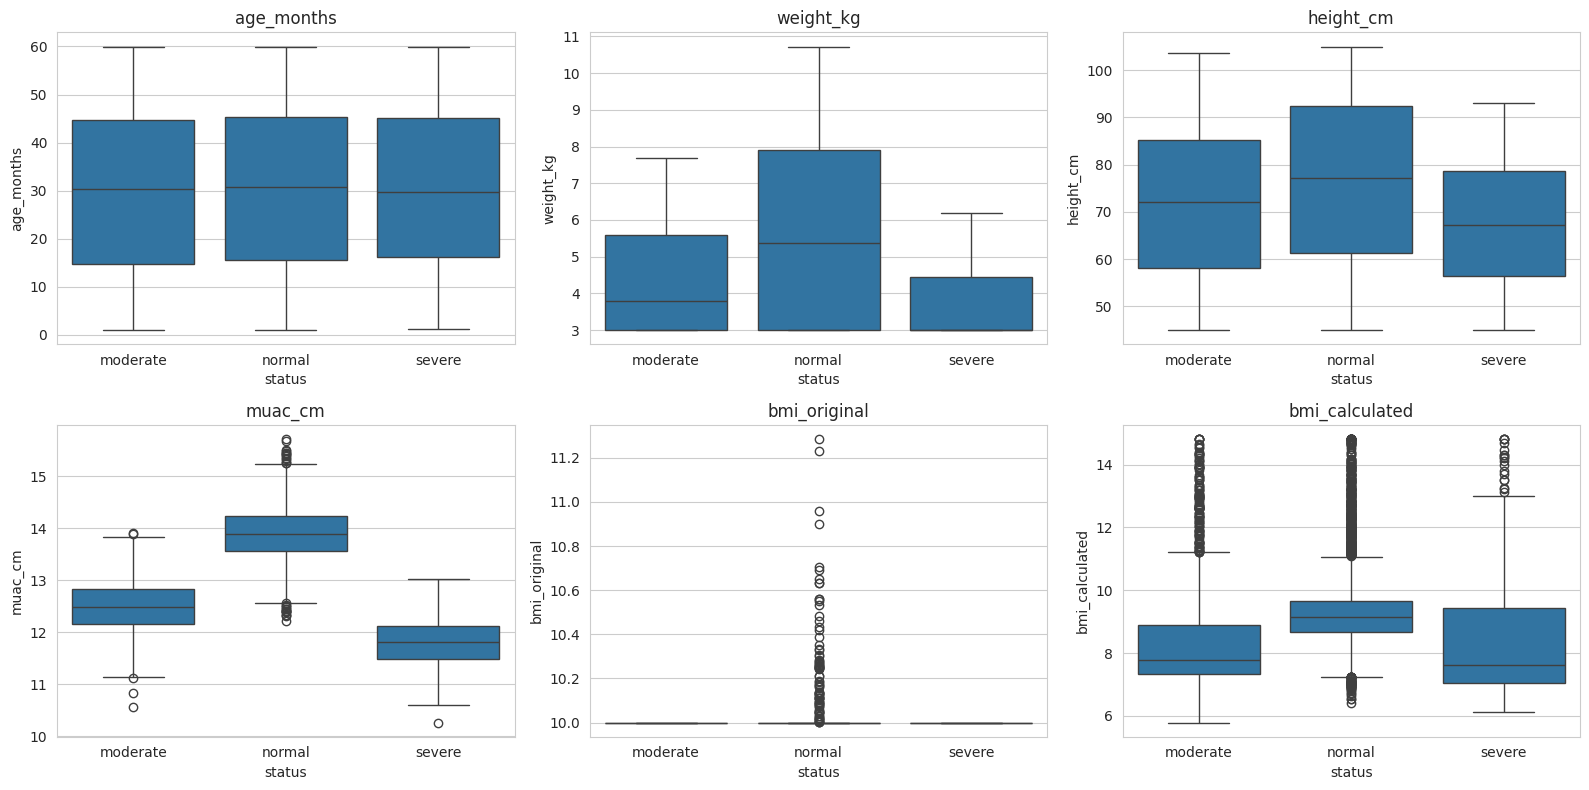


PART C — SINGLE-FEATURE DIAGNOSTIC CLASSIFIERS (depth-5 decision tree, fitted on TRAIN only)

--- age_months only | test acc=0.235 bal_acc=0.335 macro_f1=0.152 | recall: moderate=0.952, normal=0.034, severe=0.019
               pred_moderate  pred_normal  pred_severe
true_moderate            157            6            2
true_normal              488           18           27
true_severe               47            4            1

--- weight_kg only | test acc=0.317 bal_acc=0.472 macro_f1=0.267 | recall: moderate=0.097, normal=0.319, severe=1.000
               pred_moderate  pred_normal  pred_severe
true_moderate             16           10          139
true_normal               53          170          310
true_severe                0            0           52

--- height_cm only | test acc=0.228 bal_acc=0.413 macro_f1=0.208 | recall: moderate=0.097, normal=0.199, severe=0.942
               pred_moderate  pred_normal  pred_severe
true_moderate             16            5          14

In [39]:
# CELL BMI-3 — BMI placeholder analysis + target-definition audit + Jaipur compatibility
# DIAGNOSTIC ONLY: no final model retrained, raw data untouched, no BMI decision made.

import os, re, json, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, confusion_matrix

warnings.filterwarnings("ignore")
PATH_A = "/content/malnutrition_data (1).csv"
PATH_B = "/content/IND-Jaipur-2022.csv"
OUTPUT_ROOT = "/content/ayurai_malnutrition_outputs"
BMI_DIR = os.path.join(OUTPUT_ROOT, "bmi_investigation")
os.makedirs(BMI_DIR, exist_ok=True)
RANDOM_STATE = 42
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 200)

def hdr(t): print("\n" + "=" * 80); print(t); print("=" * 80)
def save_csv(df, name):
    p = os.path.join(BMI_DIR, name); df.to_csv(p, index=False); print("Saved:", p)
def pct(x, n): return 100 * x / n if n else float("nan")

# ------------------------------------------------------------------ LOAD + VERIFY
for p in [PATH_A, PATH_B]:
    if not os.path.exists(p): raise FileNotFoundError(f"{p} not found. Upload it to /content first.")
dfA_raw = pd.read_csv(PATH_A, low_memory=False)
RAW_FINGERPRINT = (dfA_raw.shape, int(pd.util.hash_pandas_object(dfA_raw, index=True).sum()))
lower = {str(c).strip().lower(): c for c in dfA_raw.columns}
required = ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi", "nutrition_status"]
miss = [c for c in required if c not in lower]
if miss:
    print("Actual columns:", list(dfA_raw.columns)); raise RuntimeError(f"Missing columns: {miss}")
C = {k: lower[k] for k in required}
num = lambda s: pd.to_numeric(s, errors="coerce")

d = pd.DataFrame({
    "age_months": num(dfA_raw[C["age_months"]]), "weight_kg": num(dfA_raw[C["weight_kg"]]),
    "height_cm": num(dfA_raw[C["height_cm"]]), "muac_cm": num(dfA_raw[C["muac_cm"]]),
    "bmi_original": num(dfA_raw[C["bmi"]]),
    "status": dfA_raw[C["nutrition_status"]].apply(lambda v: v.strip() if isinstance(v, str) else v)})
h_med = d.height_cm.median()
if not (30 <= h_med <= 220): raise RuntimeError(f"height_cm median {h_med:.2f} not plausible as cm; stop and send me this.")
valid_hw = (d.height_cm > 0) & (d.weight_kg > 0)
d["bmi_calculated"] = np.where(valid_hw, d.weight_kg / ((d.height_cm / 100) ** 2), np.nan)
d["bmi_is_10"] = (d.bmi_original == 10.0)
CLASSES = sorted(d.status.dropna().unique().tolist())
FEATS6 = ["age_months", "weight_kg", "height_cm", "muac_cm", "bmi_original", "bmi_calculated"]
FEATS4 = ["age_months", "weight_kg", "height_cm", "muac_cm"]
print("Rows:", len(d), "| classes:", CLASSES, "| missing labels:", int(d.status.isna().sum()))
print("Units: height median", round(h_med, 1), "(plausible cm); calculated BMI uses weight/(height/100)^2")

# ================================================================== PART A
hdr("PART A — IS BMI = 10 A PLACEHOLDER?  (evidence only, no assumed cause)")
rec = []   # long-format results -> bmi_placeholder_analysis.csv
n_all = len(d)
print("BMI==10 rows:", int(d.bmi_is_10.sum()), f"({pct(d.bmi_is_10.sum(), n_all):.2f}%) | BMI!=10 rows:", int((~d.bmi_is_10 & d.bmi_original.notna()).sum()),
      "| BMI missing:", int(d.bmi_original.isna().sum()))
print("\nnutrition_status counts by BMI group:")
ct = pd.crosstab(d.status, d.bmi_is_10.map({True: "bmi==10", False: "bmi!=10"}), margins=True); print(ct.to_string())
print("\nShare of each class that has BMI==10:")
for c in CLASSES:
    s = d[d.status == c]; v = pct(s.bmi_is_10.sum(), len(s)); print(f"  {c:<12} {v:6.2f}%  ({int(s.bmi_is_10.sum())}/{len(s)})")
    rec.append(dict(section="class_share_bmi10", group=c, item="pct_bmi_is_10", value=v))

for flag, g in d.groupby("bmi_is_10"):
    name = "bmi==10" if flag else "bmi!=10"
    print(f"\n--- GROUP {name}: n={len(g)} ---")
    print("status counts:", g.status.value_counts(dropna=False).to_dict())
    desc = g[["age_months", "weight_kg", "height_cm", "muac_cm"]].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(3)
    print(desc.to_string())
    for f_, r_ in desc.iterrows():
        for k_, v_ in r_.items(): rec.append(dict(section="group_stats", group=name, item=f"{f_}.{k_}", value=float(v_)))

print("\nMann-Whitney U (BMI==10 vs BMI!=10), per feature:")
a_ = d[d.bmi_is_10]; b_ = d[~d.bmi_is_10 & d.bmi_original.notna()]
for f_ in FEATS4:
    u = stats.mannwhitneyu(a_[f_].dropna(), b_[f_].dropna())
    print(f"  {f_:<11} median(10)={a_[f_].median():8.2f}  median(!=10)={b_[f_].median():8.2f}  p={u.pvalue:.3g}")
    rec.append(dict(section="mannwhitney", group="bmi10_vs_not", item=f_, value=float(u.pvalue)))

print("\nHYPOTHESIS TESTS (what the data can and cannot show):")
orig, calc = d.bmi_original, d.bmi_calculated
m = orig.notna() & calc.notna()
frac_floor = float((np.abs(orig[m] - np.maximum(10.0, calc[m])) <= 0.01).mean())
ge10 = m & (calc >= 10); lt10 = m & (calc < 10)
share10_ge = float((orig[ge10] == 10).mean()) if ge10.sum() else float("nan")
share10_lt = float((orig[lt10] == 10).mean()) if lt10.sum() else float("nan")
corr_ge = float(orig[ge10].corr(calc[ge10])) if ge10.sum() > 2 else float("nan")
print(f"  H1 'original = max(10, calculated BMI)' (clipped at a floor): matches in {100*frac_floor:.2f}% of rows")
print(f"     rows with calculated BMI >= 10: {int(ge10.sum())}; of those, original==10 in {100*share10_ge:.2f}%; corr(original, calculated) = {corr_ge:.3f}")
print(f"     rows with calculated BMI <  10: {int(lt10.sum())}; of those, original==10 in {100*share10_lt:.2f}%")
print(f"     minimum original BMI = {orig.min():.6f} (anything below 10? {int((orig < 10).sum())} rows)")
cstd = d.loc[d.bmi_is_10, "bmi_calculated"].std()
print(f"  H2 'constant default value': original is identical (10.0) in {pct(d.bmi_is_10.sum(), n_all):.2f}% of rows although calculated BMI in those rows "
      f"spans {d.loc[d.bmi_is_10,'bmi_calculated'].min():.2f}–{d.loc[d.bmi_is_10,'bmi_calculated'].max():.2f} (std {cstd:.2f})")
nz = d[~d.bmi_is_10 & d.bmi_original.notna()].copy()
print(f"  H3 'rounded value': non-10 values are written with many distinct decimals "
      f"(unique non-10 values: {nz.bmi_original.nunique()} among {len(nz)} rows; share that are multiples of 0.1: {100*np.isclose(nz.bmi_original*10, np.round(nz.bmi_original*10)).mean():.1f}%)")
print(f"  Non-10 BMI minus 10:"); print((nz.bmi_original - 10).describe().round(4).to_string())
print("  Spearman correlation of non-10 original BMI with other columns (within the non-10 group only):")
for f_ in FEATS4 + ["bmi_calculated"]:
    r = stats.spearmanr(nz.bmi_original, nz[f_], nan_policy="omit")
    print(f"     {f_:<14} rho={r.correlation:6.3f}  p={r.pvalue:.3g}"); rec.append(dict(section="spearman_nonten", group="bmi!=10", item=f_, value=float(r.correlation)))
for k_, v_ in dict(frac_floor_match=frac_floor, share10_when_calc_ge10=share10_ge, share10_when_calc_lt10=share10_lt, corr_ge10=corr_ge).items():
    rec.append(dict(section="hypothesis_tests", group="all", item=k_, value=v_))
print("\n  READING THE EVIDENCE (no cause asserted):")
print(f"   - BMI==10 is not a floor on the calculated BMI (H1 matched only {100*frac_floor:.1f}% of rows).")
print("   - It is constant across a wide range of calculated BMI, i.e. independent of height/weight.")
print("   - It is strongly tied to class: see the class-share table above.")
print("   - Whether it is a default, an imputation code or a generation artifact: The source data do not establish why the value 10.0 occurs so frequently.")
save_csv(pd.DataFrame(rec), "bmi_placeholder_analysis.csv")

# ================================================================== SPLIT (shared by Parts C, D, E)
hdr("SHARED SPLIT (70/15/15, stratified, random_state=42) — used for ALL experiments below")
use = d[d.status.notna()].copy()
idx_tr, idx_tmp = train_test_split(use.index, test_size=0.30, stratify=use.status, random_state=RANDOM_STATE)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=use.loc[idx_tmp, "status"], random_state=RANDOM_STATE)
tr, va, te = use.loc[idx_tr], use.loc[idx_va], use.loc[idx_te]
print(f"train={len(tr)} val={len(va)} test={len(te)}")
for n_, s_ in [("train", tr), ("val", va), ("test", te)]: print(f"  {n_:<6}", s_.status.value_counts().to_dict())
json.dump({"train": [int(i) for i in idx_tr], "validation": [int(i) for i in idx_va], "test": [int(i) for i in idx_te]},
          open(os.path.join(BMI_DIR, "bmi3_split_indices.json"), "w"))
print("Note: this split is made on all labelled rows (no deduplication) and may differ from the earlier production split.")
MED = tr[FEATS6].median()
def X_(frame, feats): return frame[feats].fillna(MED[feats])        # train medians only
def metr(y, p):
    out = dict(accuracy=accuracy_score(y, p), balanced_acc=balanced_accuracy_score(y, p), macro_f1=f1_score(y, p, average="macro", zero_division=0))
    for c, r in zip(CLASSES, recall_score(y, p, labels=CLASSES, average=None, zero_division=0)): out[f"recall_{c}"] = r
    return out
def cm_df(y, p):
    return pd.DataFrame(confusion_matrix(y, p, labels=CLASSES), index=[f"true_{c}" for c in CLASSES], columns=[f"pred_{c}" for c in CLASSES])

# ================================================================== PART B
hdr("PART B — ASSOCIATION BETWEEN EACH FEATURE AND nutrition_status (all labelled rows)")
sub = use.copy(); assoc = []; cls_stats = []
for f_ in FEATS6:
    groups = [sub.loc[sub.status == c, f_].dropna() for c in CLASSES]
    allv = pd.concat(groups); n_ = len(allv)
    H, p = stats.kruskal(*groups); eps2 = H / (n_ - 1)
    gm = allv.mean(); sst = ((allv - gm) ** 2).sum(); ssb = sum(len(g) * (g.mean() - gm) ** 2 for g in groups); eta2 = ssb / sst if sst > 0 else float("nan")
    xi = sub[[f_]].fillna(MED[f_]); mi = float(mutual_info_classif(xi, sub.status, random_state=RANDOM_STATE)[0])
    q = {c: (g.quantile(.05), g.quantile(.95)) for c, g in zip(CLASSES, groups)}
    disjoint = 0; pairs = 0; ov_list = []
    for i in range(len(CLASSES)):
        for j in range(i + 1, len(CLASSES)):
            lo = max(q[CLASSES[i]][0], q[CLASSES[j]][0]); hi = min(q[CLASSES[i]][1], q[CLASSES[j]][1]); ov = max(0.0, hi - lo)
            mn = min(q[CLASSES[i]][1] - q[CLASSES[i]][0], q[CLASSES[j]][1] - q[CLASSES[j]][0]); ov_list.append(ov / mn if mn > 0 else float(ov >= 0 and lo <= hi))
            pairs += 1; disjoint += int(ov == 0)
    assoc.append(dict(feature=f_, kruskal_H=H, kruskal_p=p, epsilon_sq=eps2, eta_sq=eta2, mutual_info=mi,
                      class_pairs=pairs, pairs_with_disjoint_p5_p95=disjoint, mean_p5_p95_overlap=float(np.mean(ov_list))))
    for c, g in zip(CLASSES, groups):
        cls_stats.append(dict(feature=f_, status=c, n=len(g), mean=g.mean(), std=g.std(), min=g.min(), p5=g.quantile(.05), median=g.median(), p95=g.quantile(.95), max=g.max()))
assoc = pd.DataFrame(assoc); cls_stats = pd.DataFrame(cls_stats)
print("Class-wise distributions:"); print(cls_stats.round(3).to_string(index=False))
print("\nFeature-vs-target association (epsilon_sq / eta_sq: 0=none, 1=perfect; disjoint pairs: classes whose central 90% ranges do not overlap):")
print(assoc.round(4).to_string(index=False))
save_csv(assoc, "target_feature_association.csv"); save_csv(cls_stats, "target_feature_class_stats.csv")
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for a, f_ in zip(ax.ravel(), FEATS6):
    sns.boxplot(data=sub, x="status", y=f_, order=CLASSES, ax=a); a.set_title(f_)
plt.tight_layout(); plt.savefig(os.path.join(BMI_DIR, "target_feature_boxplots.png"), dpi=120); plt.show()

# ================================================================== PART C
hdr("PART C — SINGLE-FEATURE DIAGNOSTIC CLASSIFIERS (depth-5 decision tree, fitted on TRAIN only)")
maj = tr.status.value_counts().idxmax(); rows = []
rows.append(dict(model=f"majority baseline ('{maj}')", **{f"val_{k}": v for k, v in metr(va.status, [maj] * len(va)).items() if k in ("accuracy", "balanced_acc", "macro_f1")},
                 **{f"test_{k}": v for k, v in metr(te.status, [maj] * len(te)).items()}))
single_models = {}
for f_ in FEATS6:
    clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE).fit(X_(tr, [f_]), tr.status)
    pv, pt = clf.predict(X_(va, [f_])), clf.predict(X_(te, [f_])); single_models[f_] = clf
    mv, mt = metr(va.status, pv), metr(te.status, pt)
    rows.append(dict(model=f"{f_} only", **{f"val_{k}": v for k, v in mv.items() if k in ("accuracy", "balanced_acc", "macro_f1")}, **{f"test_{k}": v for k, v in mt.items()}))
    print(f"\n--- {f_} only | test acc={mt['accuracy']:.3f} bal_acc={mt['balanced_acc']:.3f} macro_f1={mt['macro_f1']:.3f} | recall: " +
          ", ".join(f"{c}={mt['recall_'+c]:.3f}" for c in CLASSES))
    print(cm_df(te.status, pt).to_string())
single_tbl = pd.DataFrame(rows); print("\nSummary (diagnostic — NOT clinical performance):"); print(single_tbl.round(3).to_string(index=False))
save_csv(single_tbl, "single_feature_model_comparison.csv")
best_single_test_acc = float(single_tbl.iloc[1:]["test_accuracy"].max()); best_single_name = single_tbl.iloc[1:].sort_values("test_accuracy").iloc[-1]["model"]

# ================================================================== PART D
hdr("PART D — CAN nutrition_status BE RECONSTRUCTED BY SIMPLE RULES?")
print("D1. Best single threshold per class (one-vs-rest), chosen on TRAIN balanced accuracy, evaluated on TEST:")
def best_thr(x, yb):
    cand = np.unique(np.quantile(x, np.linspace(0.005, 0.995, 199))); best = None
    for t in cand:
        for dr in ("<=", ">"):
            p = (x <= t) if dr == "<=" else (x > t)
            ba = ((p[yb].mean() if yb.any() else 0) + ((~p[~yb]).mean() if (~yb).any() else 0)) / 2
            if best is None or ba > best[0]: best = (ba, float(t), dr)
    return best
thr_rows = []
for c in CLASSES:
    ytr_b = (tr.status == c).values; yte_b = (te.status == c).values
    for f_ in FEATS6:
        ba, t, dr = best_thr(X_(tr, [f_])[f_].values, ytr_b)
        xt = X_(te, [f_])[f_].values; pt = (xt <= t) if dr == "<=" else (xt > t)
        sens = pt[yte_b].mean() if yte_b.any() else np.nan; spec = (~pt[~yte_b]).mean()
        prec = yte_b[pt].mean() if pt.any() else np.nan
        thr_rows.append(dict(status=c, feature=f_, rule=f"{f_} {dr} {t:.4f}", train_bal_acc=ba, test_bal_acc=(sens + spec) / 2, test_sensitivity=sens, test_specificity=spec, test_precision=prec))
thr_tbl = pd.DataFrame(thr_rows)
for c in CLASSES:
    print(f"\n  class '{c}' — top 3 single-threshold rules by test balanced accuracy:")
    print(thr_tbl[thr_tbl.status == c].sort_values("test_bal_acc", ascending=False).head(3).round(3).to_string(index=False))
print("\nD2. Small multi-feature trees (no class weights, to read the rules) — TRAIN fit, VAL/TEST accuracy:")
tree_rows = []; trees = {}
fsets = {"all 6 features": FEATS6, "4 anthropometrics (no BMI)": FEATS4, "muac + age": ["muac_cm", "age_months"],
         "weight + height + age": ["weight_kg", "height_cm", "age_months"], "original bmi + muac": ["bmi_original", "muac_cm"]}
for nm, fs in fsets.items():
    for dep in (2, 3, 4, 6):
        t = DecisionTreeClassifier(max_depth=dep, random_state=RANDOM_STATE).fit(X_(tr, fs), tr.status); trees[(nm, dep)] = (t, fs)
        tree_rows.append(dict(feature_set=nm, depth=dep, val_acc=accuracy_score(va.status, t.predict(X_(va, fs))), test_acc=accuracy_score(te.status, t.predict(X_(te, fs))),
                              test_bal_acc=balanced_accuracy_score(te.status, t.predict(X_(te, fs)))))
tree_tbl = pd.DataFrame(tree_rows); print(tree_tbl.round(3).to_string(index=False))
for nm in ["all 6 features", "4 anthropometrics (no BMI)"]:
    t, fs = trees[(nm, 3)]; print(f"\nDepth-3 tree rules — {nm}:"); print(export_text(t, feature_names=fs))
best_tree_test_acc = float(tree_tbl.test_acc.max())
NEAR_DETERMINISTIC = max(best_single_test_acc, best_tree_test_acc) >= 0.95
print(f"Best single-feature test accuracy: {best_single_test_acc:.3f} ({best_single_name}) | best small-tree test accuracy: {best_tree_test_acc:.3f} | majority baseline: {single_tbl.iloc[0]['test_accuracy']:.3f}")
print("→ NEAR-DETERMINISTIC reconstruction from simple rules found." if NEAR_DETERMINISTIC else
      "→ No near-deterministic simple rule (>=0.95 test accuracy) found with these small models; dependence on measurements may still exist.")
print("No WHO or other thresholds were assumed; any boundaries above are purely data-driven. Labels were not changed.")
save_csv(pd.concat([thr_tbl.assign(kind="single_threshold"), tree_tbl.assign(kind="small_tree")], ignore_index=True), "target_rule_reconstruction.csv")

# ================================================================== PART E
hdr("PART E — BMI SENSITIVITY (Random Forest, same split, balanced class weights)")
cfgs = {"A: age+weight+height+MUAC": FEATS4, "B: A + original_BMI": FEATS4 + ["bmi_original"], "C: A + calculated_BMI": FEATS4 + ["bmi_calculated"]}
e_rows = []
for nm, fs in cfgs.items():
    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE).fit(X_(tr, fs), tr.status)
    pv, pt = rf.predict(X_(va, fs)), rf.predict(X_(te, fs)); mv, mt = metr(va.status, pv), metr(te.status, pt)
    e_rows.append(dict(config=nm, **{f"val_{k}": v for k, v in mv.items() if k in ("accuracy", "balanced_acc", "macro_f1")}, **{f"test_{k}": v for k, v in mt.items()}))
    print(f"\n{nm}: test acc={mt['accuracy']:.3f} bal_acc={mt['balanced_acc']:.3f} macro_f1={mt['macro_f1']:.3f}"); print(cm_df(te.status, pt).to_string())
e_tbl = pd.DataFrame(e_rows); print("\nSummary:"); print(e_tbl.round(3).to_string(index=False)); save_csv(e_tbl, "bmi_sensitivity_comparison.csv")
print("Purpose: understand BMI's effect only. Original BMI differs from BMI!=10-vs-10 structure that is tied to class (see Part A), so any gain from config B may reflect that artifact.")

# ================================================================== PART F
hdr("PART F — AGE POPULATION CHECK (Dataset A)")
am = d.age_months.dropna(); yrs = am / 12
print(f"age_months: n={len(am)} min={am.min():.1f} median={am.median():.1f} max={am.max():.1f} | years: {yrs.min():.2f}–{yrs.max():.2f}")
if am.max() <= 25: print("⚠ max age <= 25: values might be YEARS rather than months; verify.")
bands = {"under 5 years (<60 mo)": yrs < 5, "5–9 years": (yrs >= 5) & (yrs < 10), "10–12 years": (yrs >= 10) & (yrs < 13),
         "13–17 years": (yrs >= 13) & (yrs < 18), "18+ years": yrs >= 18}
age_rows = [dict(band=k, n=int(v.sum()), percent=pct(v.sum(), len(yrs))) for k, v in bands.items()]
mb = pd.cut(am, [-np.inf, 12, 24, 36, 48, 60, np.inf], labels=["0–12", "12–24", "24–36", "36–48", "48–60", ">60"]).value_counts().sort_index()
age_rows += [dict(band=f"months {k}", n=int(v), percent=pct(v, len(am))) for k, v in mb.items()]
age_tbl = pd.DataFrame(age_rows); print(age_tbl.round(2).to_string(index=False)); save_csv(age_tbl, "age_population_check.csv")
pct_u5 = pct(bands["under 5 years (<60 mo)"].sum(), len(yrs)); pct_school = pct((yrs >= 5).sum(), len(yrs))
print(f"\n→ {pct_u5:.1f}% of Dataset A is under 5 years; {pct_school:.1f}% is 5 years or older.")

# ================================================================== PART G
hdr("PART G — JAIPUR GSHS 2022 COMPATIBILITY (no merge, no model applied)")
dfB = pd.read_csv(PATH_B, low_memory=False); dfB.columns = [str(c).strip() for c in dfB.columns]
lowB = {c.lower(): c for c in dfB.columns}
print("Jaipur shape:", dfB.shape)
keys = ["de_age", "de_sex", "de_grade", "db_height", "db_weight", "db_hungry", "db_fruit", "db_veg", "db_soda", "db_ssb", "db_fat", "db_sugar", "db_underwt", "db_overwt", "db_obese"]
present = {k: lowB[k] for k in keys if k in lowB}
print("Present:", list(present), "| Absent:", [k for k in keys if k not in present])
miss_tbl = pd.DataFrame([{"column": k, "missing_pct": round(100 * dfB[v].isna().mean(), 2), "nunique": int(dfB[v].nunique())} for k, v in present.items()]); print(miss_tbl.to_string(index=False))

jrows = []
def J(item, finding): jrows.append(dict(item=item, finding=str(finding)))
# 1 age
age_B_info = "de_age absent"; age_numeric_derivable = False
if "de_age" in present:
    a = dfB[present["de_age"]]; an = num(a)
    print("\nde_age value counts (as stored):", a.value_counts(dropna=False).sort_index().to_dict())
    print(f"de_age numeric summary: min={an.min()} median={an.median()} max={an.max()} nunique={a.nunique()}")
    cat = a.nunique() <= 12
    age_B_info = f"min={an.min()}, median={an.median()}, max={an.max()}, nunique={a.nunique()}, treated_as_category_codes={cat}"
    age_numeric_derivable = not cat
    if cat: print("→ de_age has few distinct values: it looks like category codes, not exact age. Exact age ranges require the GSHS codebook, which is not in the file; no mapping is assumed here.")
J("age representation", age_B_info)
# 2 sex, grade
for k in ["de_sex", "de_grade"]:
    if k in present: print(f"\n{k}:", dfB[present[k]].value_counts(dropna=False).sort_index().to_dict()); J(k, dfB[present[k]].value_counts(dropna=False).sort_index().to_dict())
# 3 height / weight
h = num(dfB[present["db_height"]]) if "db_height" in present else pd.Series(dtype=float)
w = num(dfB[present["db_weight"]]) if "db_weight" in present else pd.Series(dtype=float)
for nm, s in [("db_height", h), ("db_weight", w)]:
    if len(s): print(f"\n{nm}: n={s.notna().sum()} min={s.min()} p1={s.quantile(.01):.2f} median={s.median():.2f} p99={s.quantile(.99):.2f} max={s.max()}"); J(nm, f"median={s.median():.3f}, min={s.min()}, max={s.max()}")
h_unit = "unknown"
if len(h):
    hm = h.dropna().median(); h_unit = "metres" if hm < 3 else ("cm" if 100 <= hm <= 220 else "unknown")
    print("Detected Jaipur height unit (plausibility only):", h_unit)
J("height unit (plausibility)", h_unit)
# 4 BMI
bmi_cols = [c for c in dfB.columns if re.search(r"bmi", c.lower())]
print("\nBMI-like columns in Jaipur:", bmi_cols or "none"); J("BMI columns present", bmi_cols or "none")
if len(h) and len(w) and h_unit in ("metres", "cm"):
    hcm = h * 100 if h_unit == "metres" else h; bj = (w / (hcm / 100) ** 2).replace([np.inf, -np.inf], np.nan)
    print(f"Diagnostic BMI computed from Jaipur height/weight (not stored in file): median={bj.median():.2f}, p1={bj.quantile(.01):.2f}, p99={bj.quantile(.99):.2f}")
    J("computed BMI (diagnostic)", f"median={bj.median():.2f}, p1={bj.quantile(.01):.2f}, p99={bj.quantile(.99):.2f}")
# 5 MUAC
muac_cols = [c for c in dfB.columns if re.search(r"muac|arm.?circ|midupper", c.lower())]
print("MUAC-like columns in Jaipur:", muac_cols or "none"); J("MUAC columns present", muac_cols or "none")
# 6 nutrition / target-like
tkeys = [present[k] for k in ["db_underwt", "db_overwt", "db_obese"] if k in present]
extra_t = [c for c in dfB.columns if re.search(r"nutri|malnut|thin|stunt|wast|underwt|overwt|obes", c.lower()) and c not in tkeys]
nutri_cols = [c for c in dfB.columns if re.search(r"hungry|food|fruit|veg|soda|ssb|fat|sugar|meal|breakfast|diet", c.lower())]
print("\nTarget-like variables:", tkeys + extra_t); print("Nutrition-behaviour variables (by name):", nutri_cols[:40])
b_vals = set()
for c in tkeys + extra_t:
    vc = dfB[c].value_counts(dropna=False).sort_index(); print(f"\n{c}: missing={100*dfB[c].isna().mean():.1f}% values={vc.to_dict()}")
    J(c, vc.to_dict()); b_vals |= set(dfB[c].dropna().astype(str).str.strip().str.lower().unique())
J("nutrition-behaviour columns", nutri_cols[:40])
# 7 label compatibility
a_vocab = set(c.lower() for c in CLASSES); overlap = a_vocab & b_vals
checks = {"Jaipur has a target using Dataset A class vocabulary (%s)" % "/".join(CLASSES): a_vocab.issubset(b_vals),
          "MUAC available in Jaipur (Dataset A input feature)": bool(muac_cols),
          "Exact age (months/years) derivable in Jaipur": bool(age_numeric_derivable),
          "Population overlap (Dataset A has >=50% aged 5+ years)": pct_school >= 50}
print("\nCOMPATIBILITY CHECKS:")
for k, v in checks.items(): print(("PASS  " if v else "FAIL  ") + k); J("check: " + k, v)
print("Label vocabulary overlap between Dataset A classes and Jaipur target values:", overlap or "none")
JAIPUR_DIRECT = all(checks.values())
if not JAIPUR_DIRECT:
    print("\nNot directly compatible for external validation of the Dataset A three-class nutrition_status target.")
    print("No label mapping was created. Jaipur remains usable for school-age population analysis and feature-availability planning only.")
J("verdict", "DIRECTLY COMPATIBLE (confirm with codebook)" if JAIPUR_DIRECT else "Not directly compatible for external validation of the Dataset A three-class nutrition_status target.")
save_csv(pd.DataFrame(jrows), "jaipur_compatibility_audit.csv")

# ================================================================== FINAL SUMMARY
hdr("FINAL SUMMARY")
nz_classes = nz.status.value_counts().to_dict()
corr_all = float(orig[m].corr(calc[m]))
print(f"1. Is original BMI usable?\n   Not as a measurement: {pct(d.bmi_is_10.sum(), n_all):.2f}% of values are the constant 10.0, correlation with weight/height-based BMI is {corr_all:.3f}, "
      f"and the {len(nz)} non-10 rows belong only to {nz_classes}. Its content is tied to the label, not to body measurements. (Final decision pending your review.)")
print(f"2. Is calculated BMI consistent with height/weight?\n   Yes by construction (weight/(height/100)^2). The ORIGINAL column is not consistent with it. Calculated BMI median is {calc.median():.2f} "
      f"(range {calc.min():.2f}–{calc.max():.2f}); this is low relative to typical human child BMI values (general knowledge, not a WHO threshold), so the height/weight values themselves "
      "may be synthetic or unusual. That is flagged, not established.")
print(f"3. Is nutrition_status apparently derived from anthropometric features?\n   Best single-feature test accuracy {best_single_test_acc:.3f} ({best_single_name}); best small-tree test accuracy {best_tree_test_acc:.3f}; "
      f"majority baseline {single_tbl.iloc[0]['test_accuracy']:.3f}. " + ("Near-deterministic simple rules exist → strongly suggests a rule-based/derived label (definition undocumented)." if NEAR_DETERMINISTIC
      else "No near-deterministic simple rule was found, but the label's definition is undocumented and dependence cannot be excluded."))
print(f"4. Evidence of target leakage?\n   Original BMI: BMI != 10 occurs only in {nz_classes}, so the BMI column leaks class information regardless of body measurements. "
      "Feature→label dependence: see item 3 and Part D.")
print(f"5. Appropriate for school-age AyurAI training?\n   {pct_u5:.1f}% of Dataset A is under 5 years; {pct_school:.1f}% is 5+ years. "
      + ("NO — it mainly represents young children." if pct_school < 50 else "Partly; see age bands.") + " It should be described as a prototype built on young-child anthropometric data.")
print("6. Is Jaipur directly compatible for external validation?\n   " + ("Automatic checks passed; confirm definitions in the codebook." if JAIPUR_DIRECT else
      "No — not directly compatible for external validation of the Dataset A three-class nutrition_status target."))
print("7. Before any final retraining:\n   a) decide the BMI handling after you review Parts A and E (the original BMI is not a valid BMI measurement);\n"
      "   b) obtain or confirm the nutrition_status definition from the dataset source;\n   c) keep the label-dependence limitation visible in all reports;\n"
      "   d) do not claim school-age validity; plan a school-age dataset with a documented nutrition outcome;\n   e) keep the same split and untouched test set for any corrected experiment.")

assert (dfA_raw.shape, int(pd.util.hash_pandas_object(dfA_raw, index=True).sum())) == RAW_FINGERPRINT, "dfA_raw changed!"
print("\n(Integrity check passed: dfA_raw fingerprint identical to the start of this cell.)")
print("\nBMI-3/Target Audit complete.")
print("Raw dataset unchanged.")
print("No final model retrained.")
print("Waiting for review before preprocessing decisions.")